In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import torch.utils.data as torch_data
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import os

In [2]:
# Load the data
df = pd.read_csv('inputFGclassifierWithLabel.CSV')

# Preprocess the data
# Drop the first column (index 0) and the 13th column (index 12)
data_processed = df.drop(df.columns[[0, 12]], axis=1)

# Select columns 2 to 19 (index 1 to 18 in Python, as index starts from 0)
features = data_processed.iloc[:, 0:17]

# Get the last 10 columns as labels
labels = data_processed.iloc[:, -10:]

# Display processed data information
print(f"Processed data shape:")
print(f"Features shape: {features.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Labels columns: {labels.columns.tolist()}")

print(f"\nFeature statistics:")
print(features.describe())

Processed data shape:
Features shape: (24528, 17)
Labels shape: (24528, 10)
Labels columns: ['LabelFillingP', 'LabelEF', 'LabelCO', 'LabelLAV', 'LabelRVO2E', 'LabelLVO2E', 'LabelLVMVO2', 'LabelRVMVO2', 'LabelLVME', 'LabelRVME']

Feature statistics:
                Sex        Height        Weight           SBP           DBP  \
count  24528.000000  24528.000000  24528.000000  24528.000000  24528.000000   
mean       0.469300    171.587851     91.603987    126.032127     74.564579   
std        0.499067      8.636087     23.191223     24.965296     16.007327   
min        0.000000    138.300000     40.400000     47.000000     29.000000   
25%        0.000000    165.500000     75.600000    109.000000     64.000000   
50%        0.000000    171.300000     88.000000    124.000000     74.000000   
75%        1.000000    177.600000    103.300000    142.000000     84.000000   
max        1.000000    207.500000    337.800000    236.000000    150.000000   

                 EF       Hed_SW       

In [3]:

# Normalize the input features
# Skip the first and last feature columns (binary variables)
continuous_features = features.iloc[:, 1:-1]
scaler = MinMaxScaler()
normalized_features = scaler.fit_transform(continuous_features)

# Combine the binary and normalized continuous features
normalized_features = pd.DataFrame(normalized_features, columns=continuous_features.columns)
normalized_features.insert(0, features.columns[0], features.iloc[:, 0])  # Add the first binary column
normalized_features[features.columns[-1]] = features.iloc[:, -1]  # Add the last binary column

# Convert normalized features to PyTorch Tensor
input_tensor = torch.tensor(normalized_features.values, dtype=torch.float32)

# Display the tensor and its size
print("Input tensor:")
print(input_tensor)
print("\nTensor size:", input_tensor.size())

Input tensor:
tensor([[1.0000, 0.4379, 0.1516,  ..., 0.1392, 0.2769, 0.0000],
        [0.0000, 0.5116, 0.1163,  ..., 0.1418, 0.3385, 1.0000],
        [0.0000, 0.6358, 0.2455,  ..., 0.1873, 0.1308, 0.0000],
        ...,
        [1.0000, 0.5520, 0.3376,  ..., 0.1823, 0.1923, 0.0000],
        [1.0000, 0.6243, 0.4593,  ..., 0.1392, 0.2385, 0.0000],
        [0.0000, 0.4942, 0.1715,  ..., 0.2380, 0.2385, 1.0000]])

Tensor size: torch.Size([24528, 17])


In [4]:
# Define the MLP model
class MLPClassifier(nn.Module):
    def __init__(self, input_size):
        super(MLPClassifier, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 64),  # First hidden layer
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.5),
            nn.Linear(64, 32),  # Second hidden layer
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.5),
            nn.Linear(32, 1),  # Output layer
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.model(x)

# Initialize the model
input_size = 17  # Number of input features
model = MLPClassifier(input_size)

# Define the loss function and optimizer
criterion = nn.BCELoss()  # Binary Cross-Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Display the model structure
print(model)

MLPClassifier(
  (model): Sequential(
    (0): Linear(in_features=17, out_features=64, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.5, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
    (9): Sigmoid()
  )
)


In [25]:
# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    input_tensor.numpy(), labels.values, test_size=0.2, random_state=42
)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

# Training parameters
batch_size = 48
num_epochs = int(5e3) 
learning_rate = 5e-4

# DataLoader for batching
import torch.utils.data as torch_data
train_dataset = torch_data.TensorDataset(X_train_tensor, y_train_tensor)
train_loader = torch_data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Directory to save models
save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)

Using device: cuda


In [26]:
# Loop through each label column
import time

for i in range(labels.shape[1]):
    label_name = labels.columns[i]  # Use label name for model identification
    start_time = time.time()
    print(f"\n{'='*60}")
    print(f"Training classifier for label {label_name}... (Label {i+1}/{labels.shape[1]})")
    print(f"{'='*60}")
    
    # Initialize model, loss function, and optimizer
    model = MLPClassifier(input_size=17).to(device)  # Move model to device
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    best_val_auc = 0.0  # Track the best validation AUC
    best_loss = float('inf')  # Track the best loss
    early_stop = False  # Early stopping flag
    epoch_count = 0  # Count actual epochs

    # Training loop
    for epoch in range(num_epochs):
        if early_stop:
            break

        epoch_count += 1
        model.train()
        epoch_loss = 0.0
        
        for batch_X, batch_y in train_loader:
            # Move data to device
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            # Select the current label column
            batch_y = batch_y[:, i].unsqueeze(1)  # Shape: (batch_size, 1)
            
            # Forward pass
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            
            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        # Validation
        model.eval()
        with torch.no_grad():
            X_val_tensor_device = X_val_tensor.to(device)  # Move validation data to device
            val_outputs = model(X_val_tensor_device)
            val_labels = y_val_tensor[:, i].unsqueeze(1).to(device)
            val_auc = roc_auc_score(val_labels.cpu().numpy(), val_outputs.cpu().numpy())

        # Check for early stopping and save best model
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_loss = epoch_loss
            # Save the best model
            model_path = os.path.join(save_dir, f"model_{label_name}_best.pth")
            torch.save(model.state_dict(), model_path)

        # Only display progress every 10 epochs or when improvement occurs
        if epoch_count % 10 == 0 or val_auc > (best_val_auc - 0.001):
            print(f"[{label_name}] Epoch {epoch+1:4d} | Best AUC: {best_val_auc:.4f} | Best Loss: {best_loss:.4f}")

        if best_val_auc >= 0.975:
            print(f"[{label_name}] ✓ Early stopping! Best AUC: {best_val_auc:.4f}")
            early_stop = True

    elapsed_time = time.time() - start_time
    print(f"[{label_name}] ✓ COMPLETED | Best AUC: {best_val_auc:.4f} | Best Loss: {best_loss:.4f} | Time: {elapsed_time:.1f}s | Epochs: {epoch_count}")


Training classifier for label LabelFillingP... (Label 1/10)
[LabelFillingP] Epoch    1 | Best AUC: 0.7820 | Best Loss: 264.4583
[LabelFillingP] Epoch    1 | Best AUC: 0.7820 | Best Loss: 264.4583
[LabelFillingP] Epoch    2 | Best AUC: 0.8078 | Best Loss: 240.2732
[LabelFillingP] Epoch    2 | Best AUC: 0.8078 | Best Loss: 240.2732
[LabelFillingP] Epoch    3 | Best AUC: 0.8233 | Best Loss: 229.8394
[LabelFillingP] Epoch    3 | Best AUC: 0.8233 | Best Loss: 229.8394
[LabelFillingP] Epoch    4 | Best AUC: 0.8300 | Best Loss: 225.0941
[LabelFillingP] Epoch    4 | Best AUC: 0.8300 | Best Loss: 225.0941
[LabelFillingP] Epoch    5 | Best AUC: 0.8329 | Best Loss: 220.3769
[LabelFillingP] Epoch    5 | Best AUC: 0.8329 | Best Loss: 220.3769
[LabelFillingP] Epoch    6 | Best AUC: 0.8367 | Best Loss: 219.8404
[LabelFillingP] Epoch    6 | Best AUC: 0.8367 | Best Loss: 219.8404
[LabelFillingP] Epoch    8 | Best AUC: 0.8410 | Best Loss: 215.2043
[LabelFillingP] Epoch    8 | Best AUC: 0.8410 | Best Lo

MODEL EVALUATION AND VISUALIZATION

Evaluating LabelFillingP...


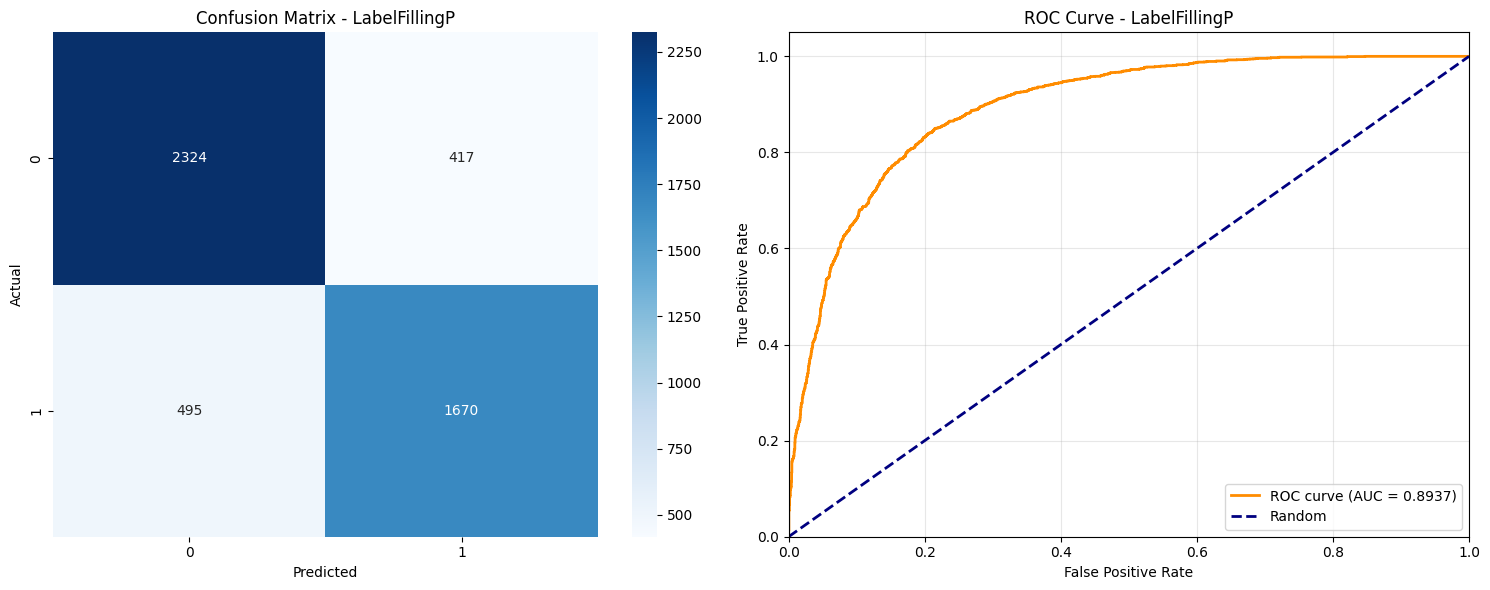

AUC: 0.8937
Accuracy: 0.8141
Precision: 0.8002
Recall: 0.7714
F1-Score: 0.7855

Evaluating LabelEF...


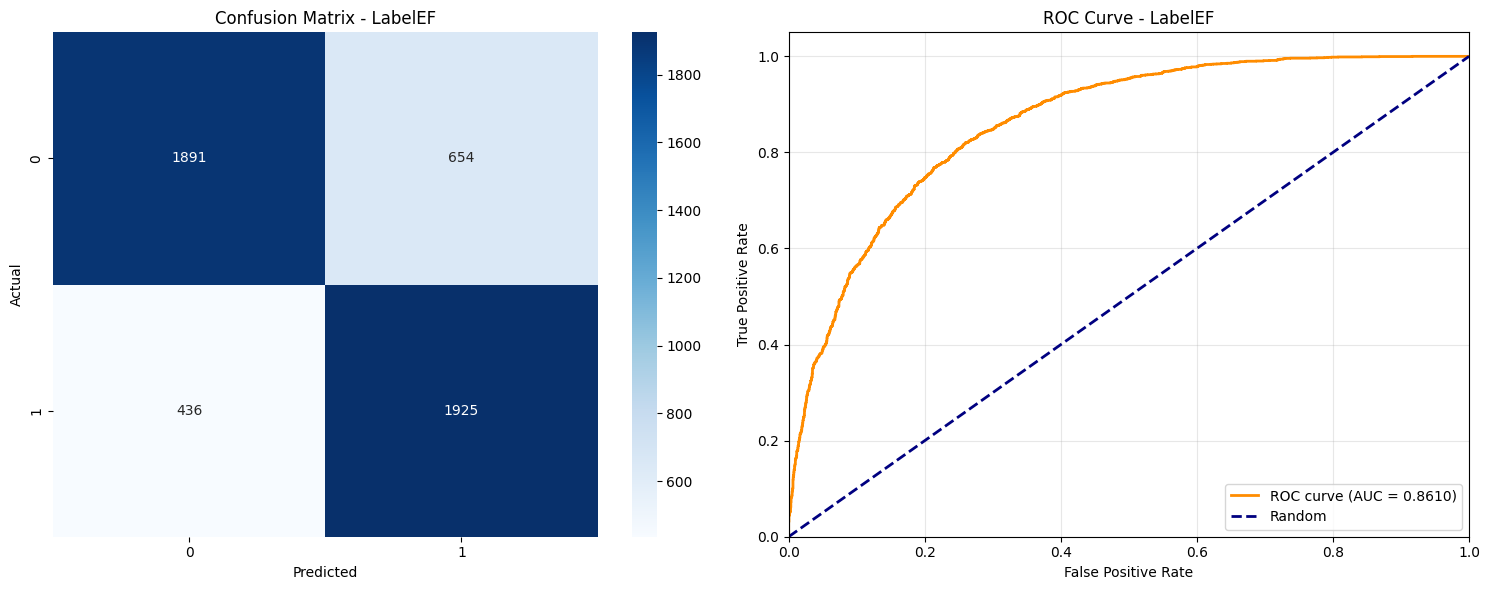

AUC: 0.8610
Accuracy: 0.7778
Precision: 0.7464
Recall: 0.8153
F1-Score: 0.7794

Evaluating LabelCO...


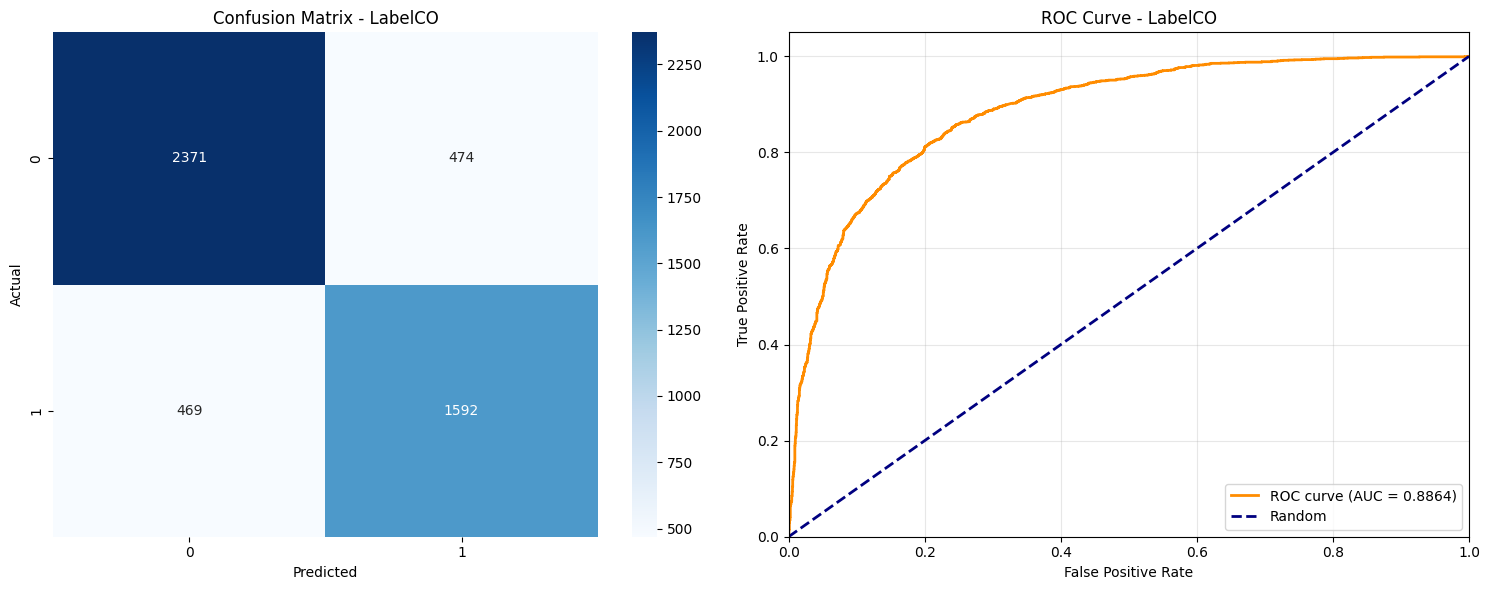

AUC: 0.8864
Accuracy: 0.8078
Precision: 0.7706
Recall: 0.7724
F1-Score: 0.7715

Evaluating LabelLAV...


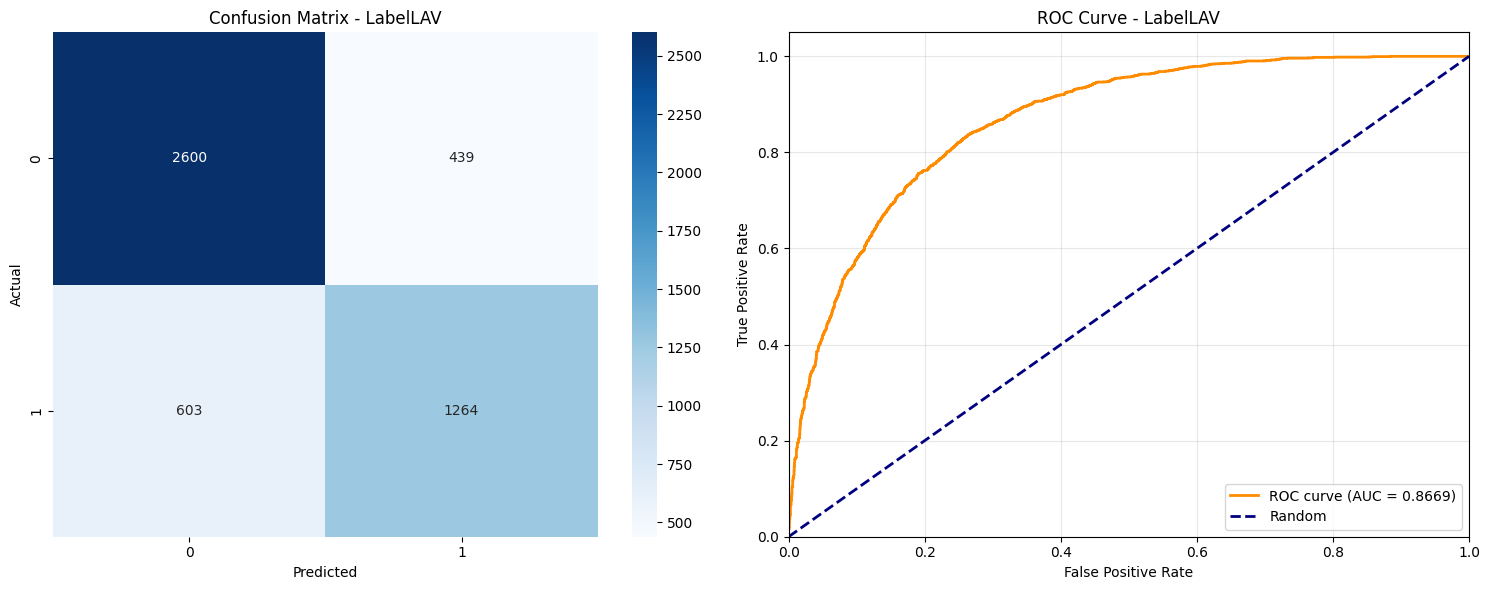

AUC: 0.8669
Accuracy: 0.7876
Precision: 0.7422
Recall: 0.6770
F1-Score: 0.7081

Evaluating LabelRVO2E...


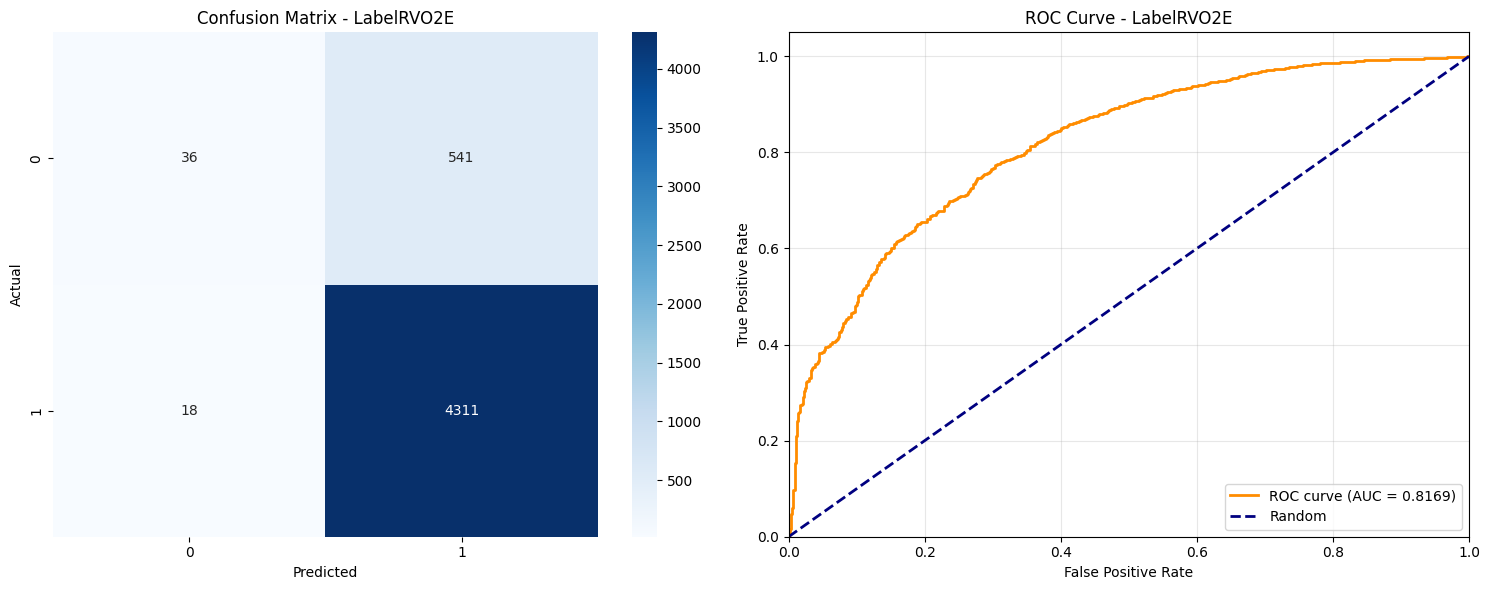

AUC: 0.8169
Accuracy: 0.8861
Precision: 0.8885
Recall: 0.9958
F1-Score: 0.9391

Evaluating LabelLVO2E...


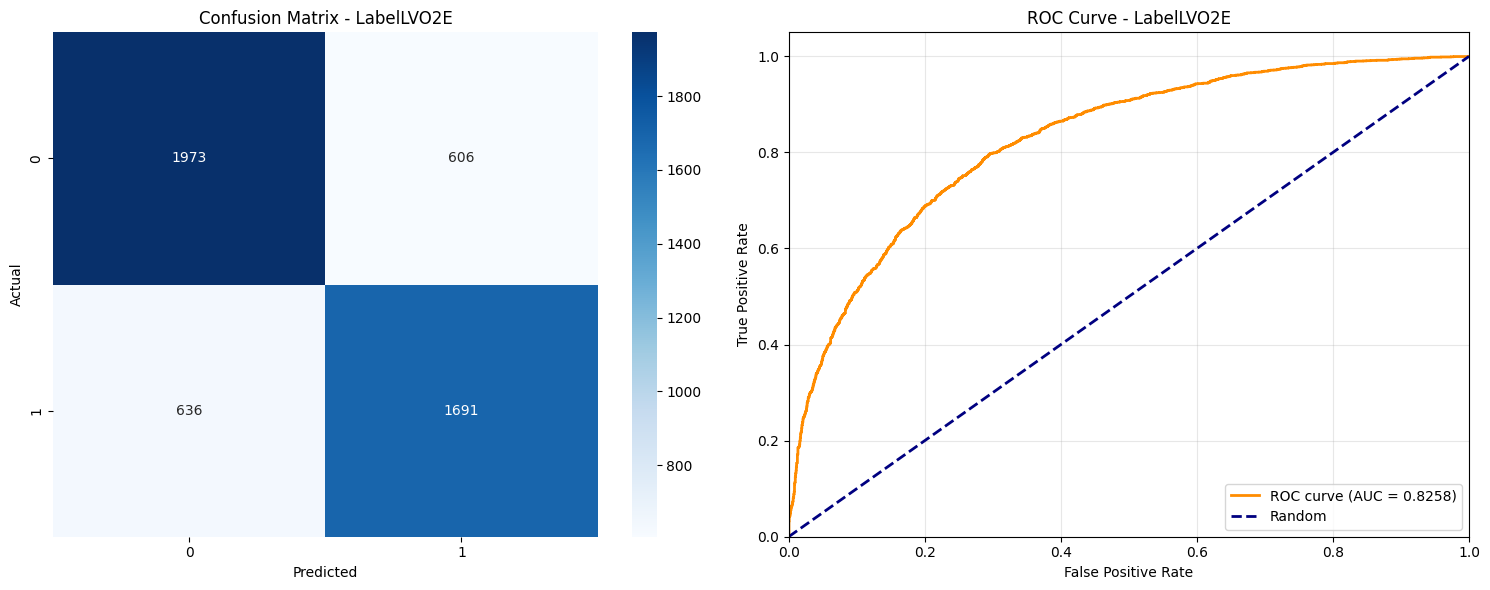

AUC: 0.8258
Accuracy: 0.7468
Precision: 0.7362
Recall: 0.7267
F1-Score: 0.7314

Evaluating LabelLVMVO2...


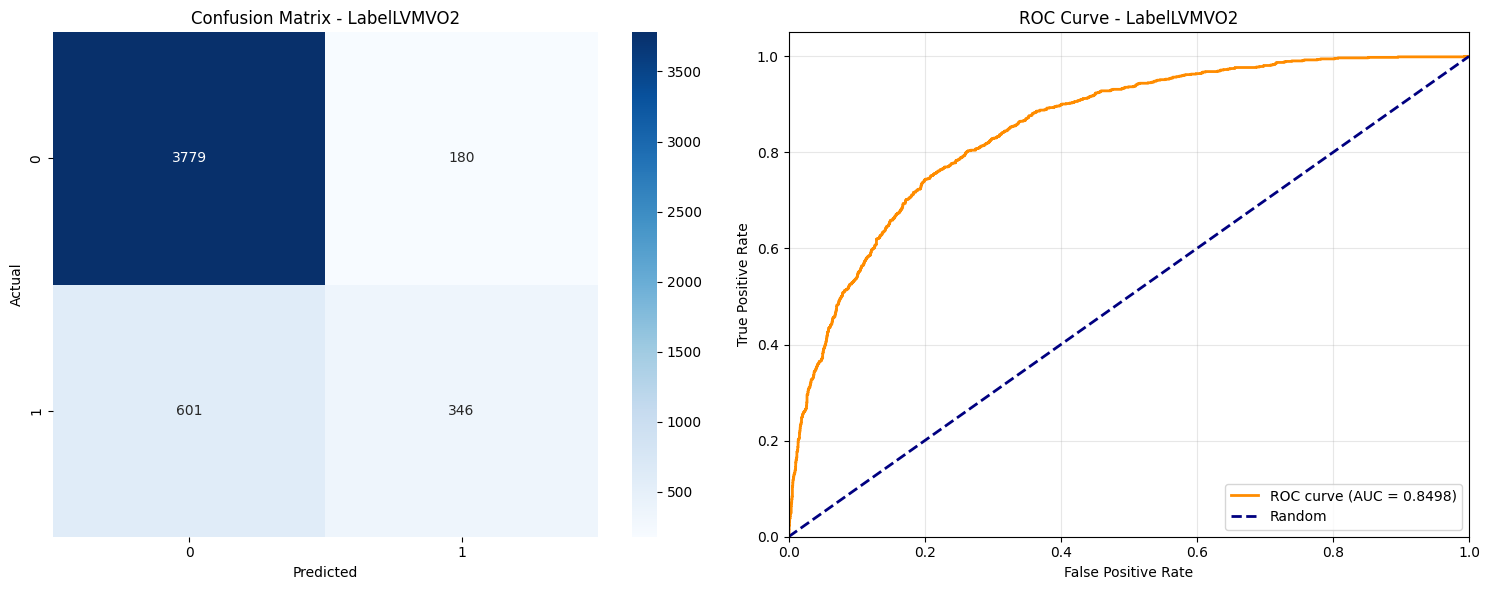

AUC: 0.8498
Accuracy: 0.8408
Precision: 0.6578
Recall: 0.3654
F1-Score: 0.4698

Evaluating LabelRVMVO2...


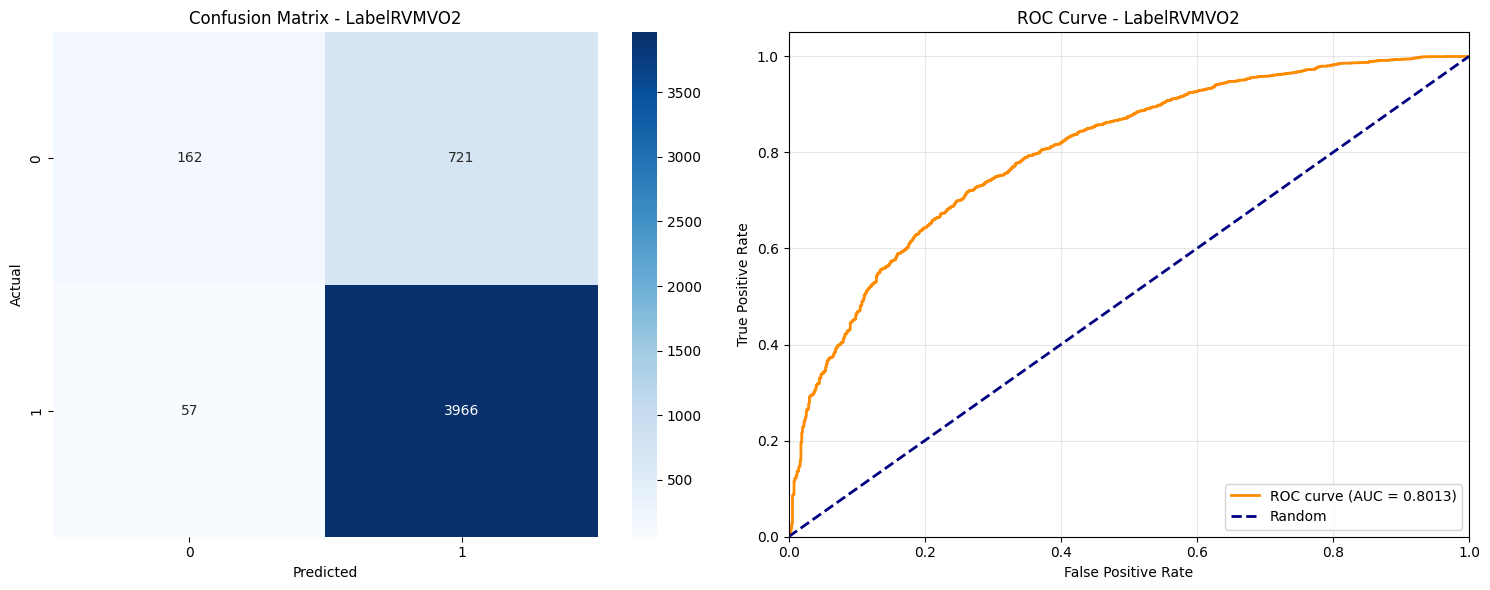

AUC: 0.8013
Accuracy: 0.8414
Precision: 0.8462
Recall: 0.9858
F1-Score: 0.9107

Evaluating LabelLVME...


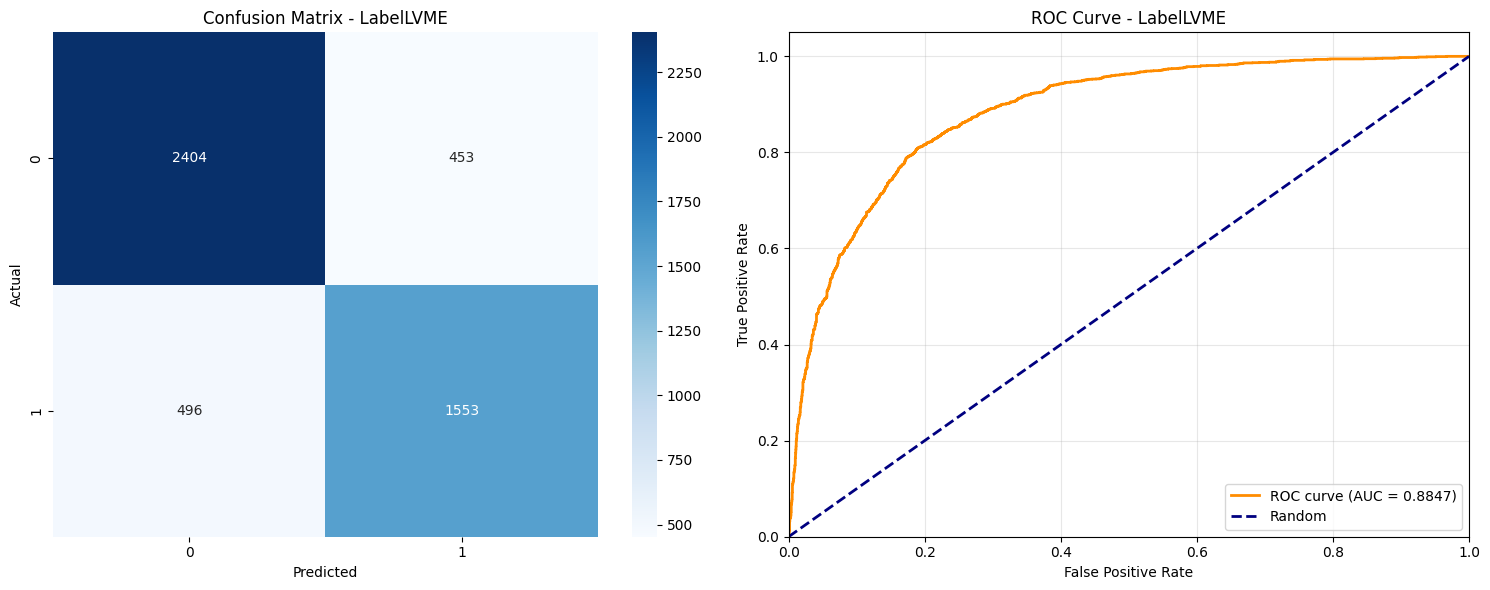

AUC: 0.8847
Accuracy: 0.8066
Precision: 0.7742
Recall: 0.7579
F1-Score: 0.7660

Evaluating LabelRVME...


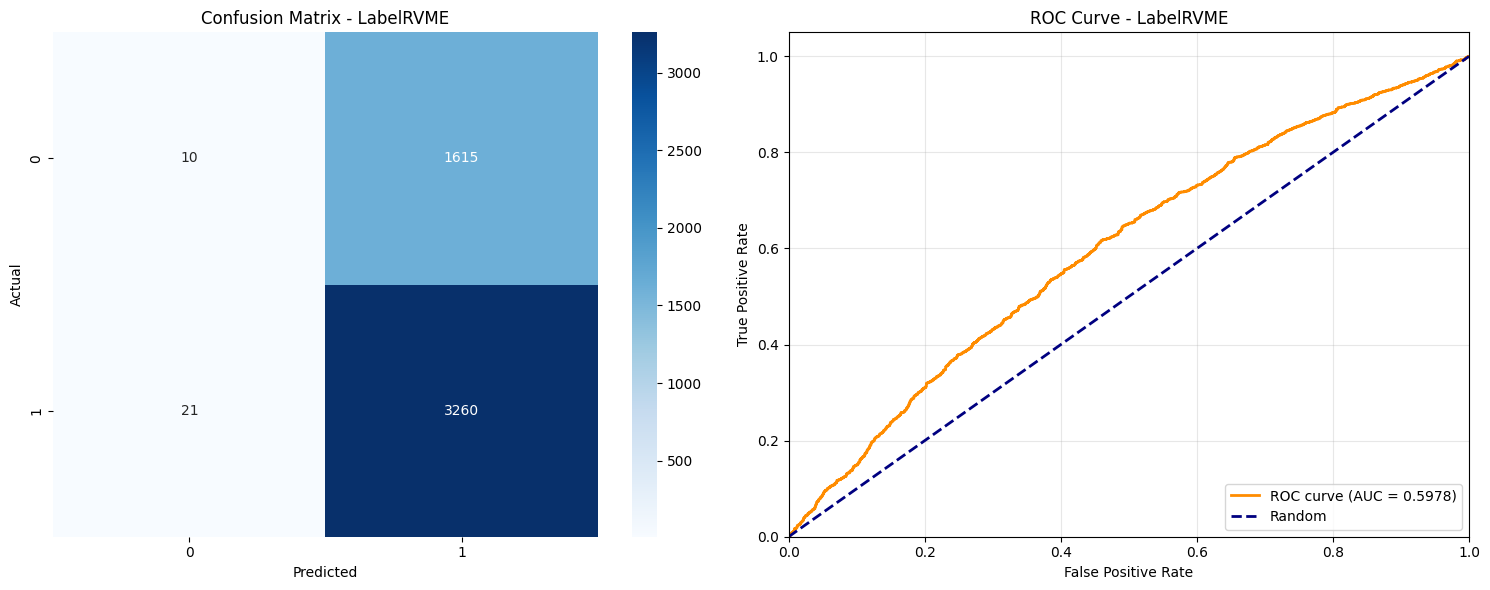

AUC: 0.5978
Accuracy: 0.6665
Precision: 0.6687
Recall: 0.9936
F1-Score: 0.7994

EVALUATION COMPLETED!
All plots saved in: evaluation_plots/


In [32]:
# Model Evaluation and Visualization
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create directory for saving plots
plot_dir = "evaluation_plots"
os.makedirs(plot_dir, exist_ok=True)

print("="*80)
print("MODEL EVALUATION AND VISUALIZATION")
print("="*80)

# Dictionary to store all results
evaluation_results = {}

# Load and evaluate each trained model
for i in range(labels.shape[1]):
    label_name = labels.columns[i]
    print(f"\nEvaluating {label_name}...")
    
    # Load the best model
    model_path = os.path.join(save_dir, f"model_{label_name}_best.pth")
    if os.path.exists(model_path):
        # Initialize and load model
        eval_model = MLPClassifier(input_size=17).to(device)
        eval_model.load_state_dict(torch.load(model_path, map_location=device))
        eval_model.eval()
        
        # Get predictions
        with torch.no_grad():
            X_val_tensor_device = X_val_tensor.to(device)
            val_outputs = eval_model(X_val_tensor_device)
            val_probs = val_outputs.cpu().numpy().flatten()
            val_preds = (val_probs > 0.5).astype(int)
            val_true = y_val_tensor[:, i].numpy().astype(int)
        
        # Calculate metrics
        val_auc = roc_auc_score(val_true, val_probs)
        
        # Confusion Matrix
        cm = confusion_matrix(val_true, val_preds)
        
        # Classification Report
        report = classification_report(val_true, val_preds, output_dict=True)
        
        # ROC Curve
        fpr, tpr, thresholds = roc_curve(val_true, val_probs)
        roc_auc = auc(fpr, tpr)
        
        # Store results
        evaluation_results[label_name] = {
            'confusion_matrix': cm,
            'classification_report': report,
            'auc': val_auc,
            'fpr': fpr,
            'tpr': tpr,
            'roc_auc': roc_auc,
            'predictions': val_preds,
            'probabilities': val_probs,
            'true_labels': val_true
        }
        
        # Create subplot figure for this label
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        
        # Plot Confusion Matrix
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
        axes[0].set_title(f'Confusion Matrix - {label_name}')
        axes[0].set_xlabel('Predicted')
        axes[0].set_ylabel('Actual')
        
        # Plot ROC Curve
        axes[1].plot(fpr, tpr, color='darkorange', lw=2, 
                    label=f'ROC curve (AUC = {roc_auc:.4f})')
        axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
        axes[1].set_xlim([0.0, 1.0])
        axes[1].set_ylim([0.0, 1.05])
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title(f'ROC Curve - {label_name}')
        axes[1].legend(loc="lower right")
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(os.path.join(plot_dir, f'{label_name}_evaluation.png'), dpi=300, bbox_inches='tight')
        plt.show()
        
        # Print metrics
        print(f"AUC: {val_auc:.4f}")
        print(f"Accuracy: {report['accuracy']:.4f}")
        print(f"Precision: {report['1']['precision']:.4f}")
        print(f"Recall: {report['1']['recall']:.4f}")
        print(f"F1-Score: {report['1']['f1-score']:.4f}")
        
    else:
        print(f"Model file not found: {model_path}")

print("\n" + "="*80)
print("EVALUATION COMPLETED!")
print(f"All plots saved in: {plot_dir}/")
print("="*80)

DETAILED LABEL ANALYSIS

1. Label Distribution:
--------------------------------------------------
LabelFillingP   | Positive: 10753 (0.438) | Negative: 13775 (0.562) | Ratio: 0.781
LabelEF         | Positive: 11817 (0.482) | Negative: 12711 (0.518) | Ratio: 0.930
LabelCO         | Positive: 10227 (0.417) | Negative: 14301 (0.583) | Ratio: 0.715
LabelLAV        | Positive: 9329 (0.380) | Negative: 15199 (0.620) | Ratio: 0.614
LabelRVO2E      | Positive: 21510 (0.877) | Negative: 3018 (0.123) | Ratio: 7.127
LabelLVO2E      | Positive: 11965 (0.488) | Negative: 12563 (0.512) | Ratio: 0.952
LabelLVMVO2     | Positive: 4851 (0.198) | Negative: 19677 (0.802) | Ratio: 0.247
LabelRVMVO2     | Positive: 20078 (0.819) | Negative: 4450 (0.181) | Ratio: 4.512
LabelLVME       | Positive: 10250 (0.418) | Negative: 14278 (0.582) | Ratio: 0.718
LabelRVME       | Positive: 16333 (0.666) | Negative: 8195 (0.334) | Ratio: 1.993

2. Label Correlation Matrix:
----------------------------------------------

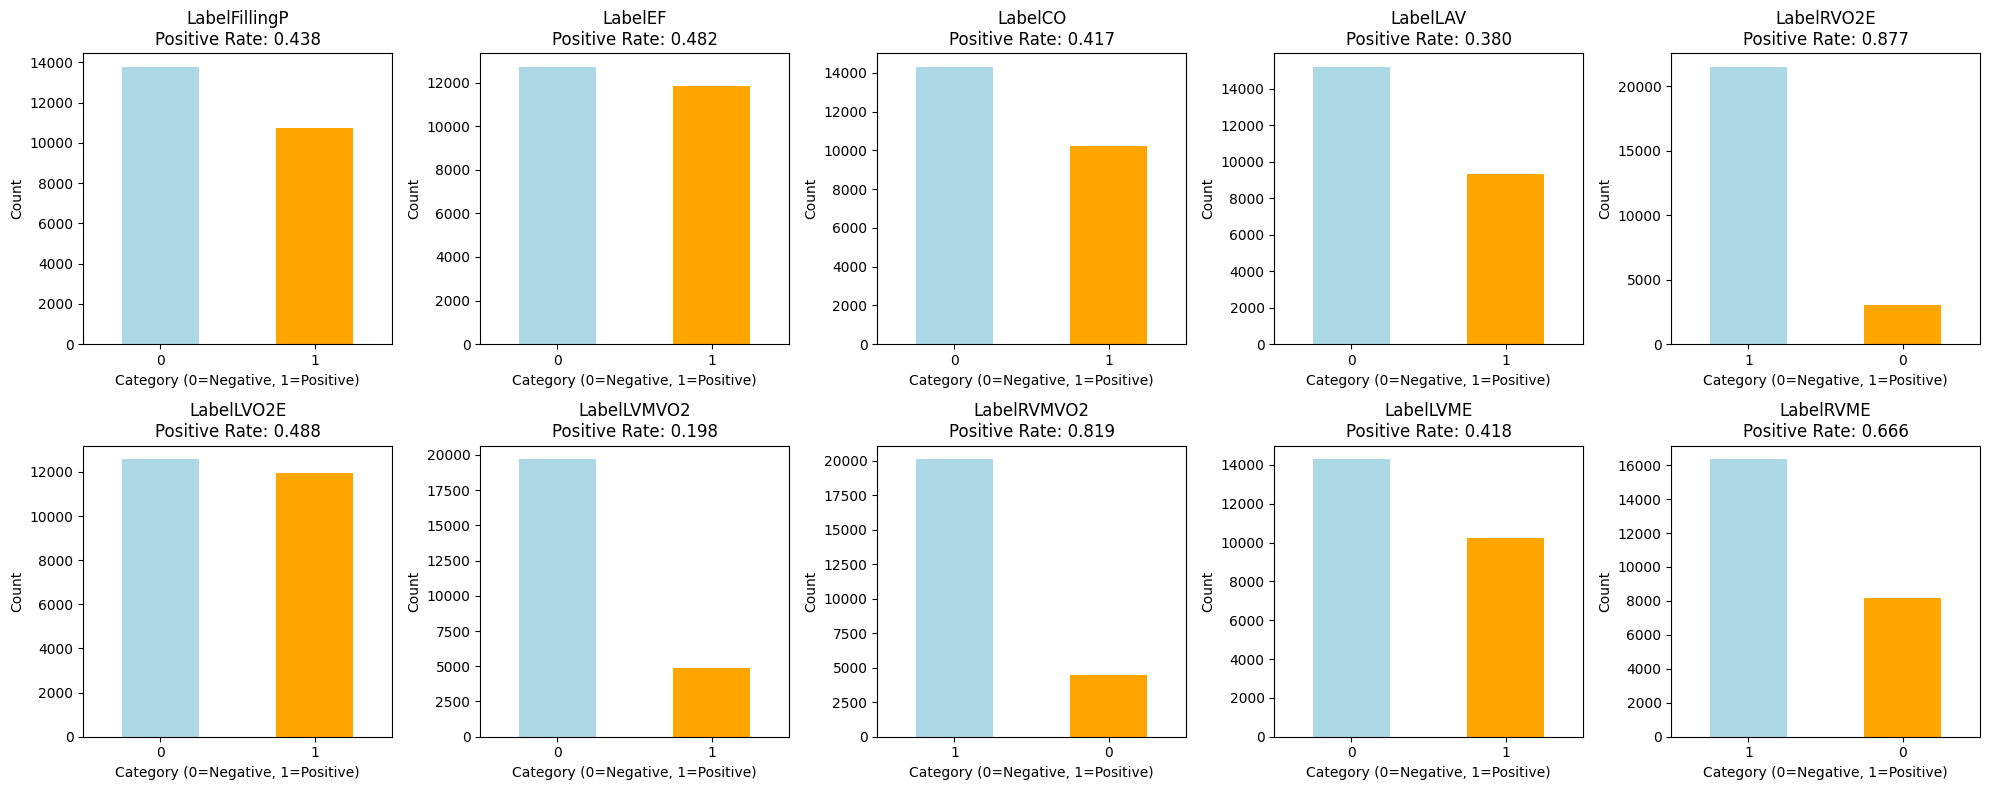


3. LabelRVME vs Other Labels Analysis:
--------------------------------------------------
LabelFillingP   vs LabelRVME: χ²=379.616, p=0.0000, Cramér's V=0.124
LabelEF         vs LabelRVME: χ²=166.061, p=0.0000, Cramér's V=0.082
LabelCO         vs LabelRVME: χ²=348.991, p=0.0000, Cramér's V=0.119
LabelLAV        vs LabelRVME: χ²=172.778, p=0.0000, Cramér's V=0.084
LabelRVO2E      vs LabelRVME: χ²=413.039, p=0.0000, Cramér's V=0.130
LabelLVO2E      vs LabelRVME: χ²=16.087, p=0.0001, Cramér's V=0.026
LabelLVMVO2     vs LabelRVME: χ²=53.759, p=0.0000, Cramér's V=0.047
LabelRVMVO2     vs LabelRVME: χ²=297.138, p=0.0000, Cramér's V=0.110
LabelLVME       vs LabelRVME: χ²=382.006, p=0.0000, Cramér's V=0.125

4. Feature Correlation with LabelRVME:
--------------------------------------------------
Feature  1 (Sex            ): -0.0208
Feature  2 (Height         ): 0.0068
Feature  3 (Weight         ): -0.0095
Feature  4 (SBP            ): 0.0338
Feature  5 (DBP            ): 0.0314
Feature  6 (

In [34]:
# 详细分析标签分布和相关性
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

print("="*80)
print("DETAILED LABEL ANALYSIS")
print("="*80)

# 1. 检查每个标签的类别分布
print("\n1. Label Distribution:")
print("-" * 50)
for i, col in enumerate(labels.columns):
    pos_count = labels[col].sum()
    neg_count = len(labels) - pos_count
    pos_ratio = pos_count / len(labels)
    print(f"{col:15s} | Positive: {pos_count:4d} ({pos_ratio:.3f}) | Negative: {neg_count:4d} ({1-pos_ratio:.3f}) | Ratio: {pos_count/neg_count:.3f}")

# 2. 标签之间的相关性矩阵
print(f"\n2. Label Correlation Matrix:")
print("-" * 50)
label_corr = labels.corr()
print(label_corr.round(3))

# 3. 可视化标签分布
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(labels.columns):
    labels[col].value_counts().plot(kind='bar', ax=axes[i], color=['lightblue', 'orange'])
    axes[i].set_title(f'{col}\nPositive Rate: {labels[col].mean():.3f}')
    axes[i].set_xlabel('Category (0=Negative, 1=Positive)')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('label_distribution_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. 检查最后一个标签与其他标签的关系
last_label = labels.columns[-1]
print(f"\n3. {last_label} vs Other Labels Analysis:")
print("-" * 50)

# 计算与其他标签的卡方检验
for col in labels.columns[:-1]:
    # 创建列联表
    contingency_table = pd.crosstab(labels[col], labels[last_label])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    
    # 计算Cramér's V (关联强度)
    n = contingency_table.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))
    
    print(f"{col:15s} vs {last_label}: χ²={chi2:.3f}, p={p_value:.4f}, Cramér's V={cramers_v:.3f}")

# 5. 特征与最后一个标签的相关性
print(f"\n4. Feature Correlation with {last_label}:")
print("-" * 50)
feature_label_corr = []
for i, feat_col in enumerate(features.columns):
    corr = np.corrcoef(features[feat_col], labels[last_label])[0, 1]
    feature_label_corr.append((feat_col, corr))
    print(f"Feature {i+1:2d} ({feat_col:15s}): {corr:.4f}")

# 排序显示最相关的特征
feature_label_corr.sort(key=lambda x: abs(x[1]), reverse=True)
print(f"\nTop 5 Most Correlated Features:")
for feat, corr in feature_label_corr[:5]:
    print(f"{feat:15s}: {corr:.4f}")

In [35]:
# 深度分析 LabelRVME 的问题
print("\n" + "="*80)
print("LabelRVME In-depth Problem Analysis")
print("="*80)

last_label = 'LabelRVME'
last_label_idx = list(labels.columns).index(last_label)

# 1. 检查特征相关性强度
print(f"\n1. {last_label} Feature Correlation Issue:")
print("-" * 50)
max_corr = max([abs(np.corrcoef(features.iloc[:, i], labels[last_label])[0, 1]) for i in range(len(features.columns))])
print(f"Maximum correlation with features: {max_corr:.4f}")
print("⚠️  All feature correlations are extremely low (<0.1), this is the main cause of poor performance!")

# 2. 类别不平衡分析
pos_ratio = labels[last_label].mean()
imbalance_ratio = (1-pos_ratio) / pos_ratio if pos_ratio > 0 else float('inf')
print(f"\n2. Class Imbalance Analysis:")
print("-" * 50)
print(f"Positive ratio: {pos_ratio:.3f}")
print(f"Negative ratio: {1-pos_ratio:.3f}")
print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")

if imbalance_ratio > 2:
    print("⚠️  Moderate class imbalance detected")

# 3. 与其他标签的共线性检查
print(f"\n3. Correlation Analysis with Other Labels:")
print("-" * 50)
other_label_corrs = []
for col in labels.columns:
    if col != last_label:
        corr = labels[col].corr(labels[last_label])
        other_label_corrs.append((col, corr))
        
other_label_corrs.sort(key=lambda x: abs(x[1]), reverse=True)
print("Correlations with other labels (sorted by strength):")
for label, corr in other_label_corrs[:5]:
    print(f"  {label:15s}: {corr:.4f}")

# 4. 检查训练数据的可分性
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

print(f"\n4. Data Separability Test:")
print("-" * 50)

# 使用简单的逻辑回归测试
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train[:, last_label_idx])
lr_pred_proba = lr.predict_proba(X_val)[:, 1]
lr_auc = roc_auc_score(y_val[:, last_label_idx], lr_pred_proba)

print(f"Logistic Regression baseline AUC: {lr_auc:.4f}")
if lr_auc < 0.7:
    print("⚠️  Even linear models perform poorly, data itself may have issues")

# 5. 检查噪声水平
print(f"\n5. Data Quality Analysis:")
print("-" * 50)

# 计算特征的信息增益
from sklearn.feature_selection import mutual_info_classif
mi_scores = mutual_info_classif(X_train, y_train[:, last_label_idx], random_state=42)
max_mi = max(mi_scores)
print(f"Maximum mutual information score: {max_mi:.4f}")
if max_mi < 0.1:
    print("⚠️  Low mutual information between features and target, possible noise")

# 6. 建议的解决方案
print(f"\n6. Suggested Solutions:")
print("-" * 50)
print("Possible reasons for poor LabelRVME performance:")
print("1. Extremely low feature correlation - existing features contribute little")
print("2. Data may contain noise or annotation errors")
print("3. Need more relevant features or feature engineering")
print("\nRecommended approaches:")
print("• Feature combinations/interactions")
print("• Different loss functions (Focal Loss for imbalance)")
print("• Ensemble methods")
print("• Data cleaning and re-annotation")


LabelRVME In-depth Problem Analysis

1. LabelRVME Feature Correlation Issue:
--------------------------------------------------
Maximum correlation with features: 0.0858
⚠️  All feature correlations are extremely low (<0.1), this is the main cause of poor performance!

2. Class Imbalance Analysis:
--------------------------------------------------
Positive ratio: 0.666
Negative ratio: 0.334
Imbalance ratio: 0.50:1

3. Correlation Analysis with Other Labels:
--------------------------------------------------
Correlations with other labels (sorted by strength):
  LabelRVO2E     : 0.1299
  LabelLVME      : 0.1249
  LabelFillingP  : 0.1245
  LabelCO        : 0.1194
  LabelRVMVO2    : 0.1102

4. Data Separability Test:
--------------------------------------------------
Logistic Regression baseline AUC: 0.5855
⚠️  Even linear models perform poorly, data itself may have issues

5. Data Quality Analysis:
--------------------------------------------------
Maximum mutual information score: 0.00


Neural Network Complexity Impact Analysis for LabelRVME

Analysis on whether to increase neural network complexity (more neurons/hidden layers):

🔍 Current Network Structure: 17 → 64 → 32 → 1
📊 Data Scale: ~25,000 samples, 17 features

❌ Why increasing complexity may be ineffective:

1. Extremely low feature correlation (max=0.086)
   • Even with infinite model capacity, cannot extract useful info from uncorrelated features
   • This is a data problem, not a model problem

2. Overfitting risk
   • Current dropout=0.5 is already high, indicating model prone to overfitting
   • More complex models will exacerbate this issue
   • Validation AUC stagnating at 0.6 suggests model reached data's information limit

3. Simple baseline performs equally poorly
   • Logistic regression AUC=0.585, barely different from complex MLP
   • Indicates poor linear/non-linear separability of data

✅ More effective approaches:

1. Feature Engineering > Model Complexity
   • Feature interactions: LVEDV × LV

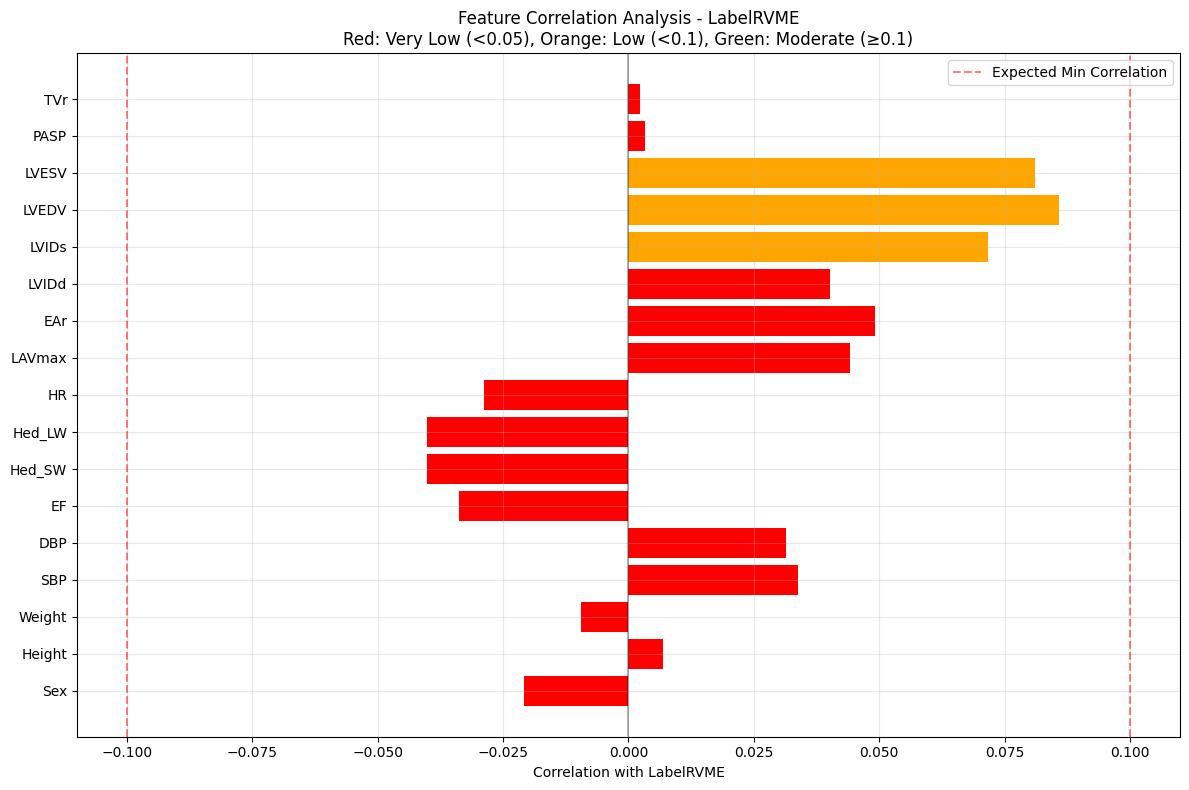

Average absolute correlation of all features: 0.0366
📊 Conclusion: Average correlation extremely low, increasing model complexity won't significantly improve performance


In [36]:
# 关于神经网络复杂度的分析
print("\n" + "="*80)
print("Neural Network Complexity Impact Analysis for LabelRVME")
print("="*80)

print("""
Analysis on whether to increase neural network complexity (more neurons/hidden layers):

🔍 Current Network Structure: 17 → 64 → 32 → 1
📊 Data Scale: ~25,000 samples, 17 features

❌ Why increasing complexity may be ineffective:

1. Extremely low feature correlation (max=0.086)
   • Even with infinite model capacity, cannot extract useful info from uncorrelated features
   • This is a data problem, not a model problem

2. Overfitting risk
   • Current dropout=0.5 is already high, indicating model prone to overfitting
   • More complex models will exacerbate this issue
   • Validation AUC stagnating at 0.6 suggests model reached data's information limit

3. Simple baseline performs equally poorly
   • Logistic regression AUC=0.585, barely different from complex MLP
   • Indicates poor linear/non-linear separability of data

✅ More effective approaches:

1. Feature Engineering > Model Complexity
   • Feature interactions: LVEDV × LVESV
   • Feature ratios: LVESV/LVEDV
   • Domain knowledge-driven feature combinations

2. Data Quality Improvement
   • Check annotation consistency
   • Outlier handling
   • Add more relevant features

3. Loss Function Optimization
   • Focal Loss for hard samples
   • Class-balanced loss
   • Custom weights

📊 Suggested experiment order:
1. Try feature engineering first (low cost, potentially significant effect)
2. Check data quality
3. Only then consider model complexity adjustments

Conclusion: With extremely low feature correlation, increasing neural network complexity 
           is usually ineffective and potentially harmful. Should prioritize data and 
           feature issues first.
""")

# 可视化特征重要性
print("\nFeature Correlation with LabelRVME Visualization:")
feature_names = features.columns.tolist()
correlations = [np.corrcoef(features[col], labels['LabelRVME'])[0, 1] for col in feature_names]

plt.figure(figsize=(12, 8))
colors = ['red' if abs(c) < 0.05 else 'orange' if abs(c) < 0.1 else 'green' for c in correlations]
bars = plt.barh(range(len(feature_names)), correlations, color=colors)
plt.yticks(range(len(feature_names)), feature_names)
plt.xlabel('Correlation with LabelRVME')
plt.title('Feature Correlation Analysis - LabelRVME\nRed: Very Low (<0.05), Orange: Low (<0.1), Green: Moderate (≥0.1)')
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.axvline(x=0.1, color='red', linestyle='--', alpha=0.5, label='Expected Min Correlation')
plt.axvline(x=-0.1, color='red', linestyle='--', alpha=0.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('feature_correlation_RVME.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Average absolute correlation of all features: {np.mean([abs(c) for c in correlations]):.4f}")
print("📊 Conclusion: Average correlation extremely low, increasing model complexity won't significantly improve performance")

EXTERNAL VALIDATION SET EVALUATION
✓ Successfully loaded external validation data: inputFGclassifier146.CSV

External validation data shape:
Features shape: (146, 17)
Labels shape: (146, 10)
External validation tensor size: torch.Size([146, 17])
External validation labels columns: ['LabelFillingP', 'LabelEF', 'LabelCO', 'LabelLAV', 'LabelRVO2E', 'LabelLVO2E', 'LabelLVMVO2', 'LabelRVMVO2', 'LabelLVME', 'LabelRVME']

EVALUATING ALL CLASSIFIERS ON EXTERNAL VALIDATION SET

External Validation: LabelFillingP


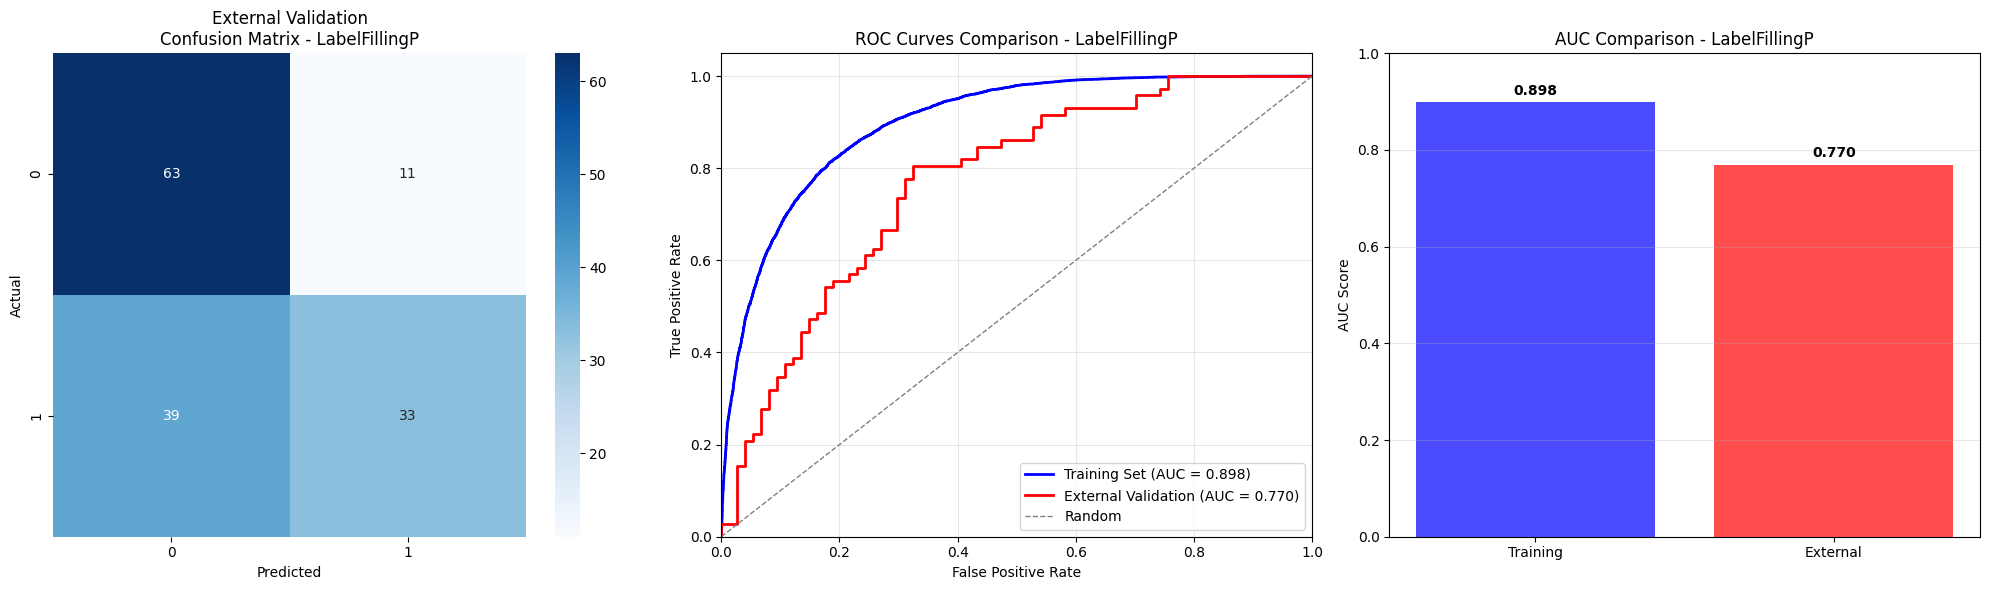

External Validation Results:
  AUC: 0.7697
  Accuracy: 0.6575
  Precision: 0.7500
  Recall: 0.4583
  F1-Score: 0.5690
Training vs External AUC Difference: 0.1284
⚠️  Large performance drop detected - possible overfitting

External Validation: LabelEF


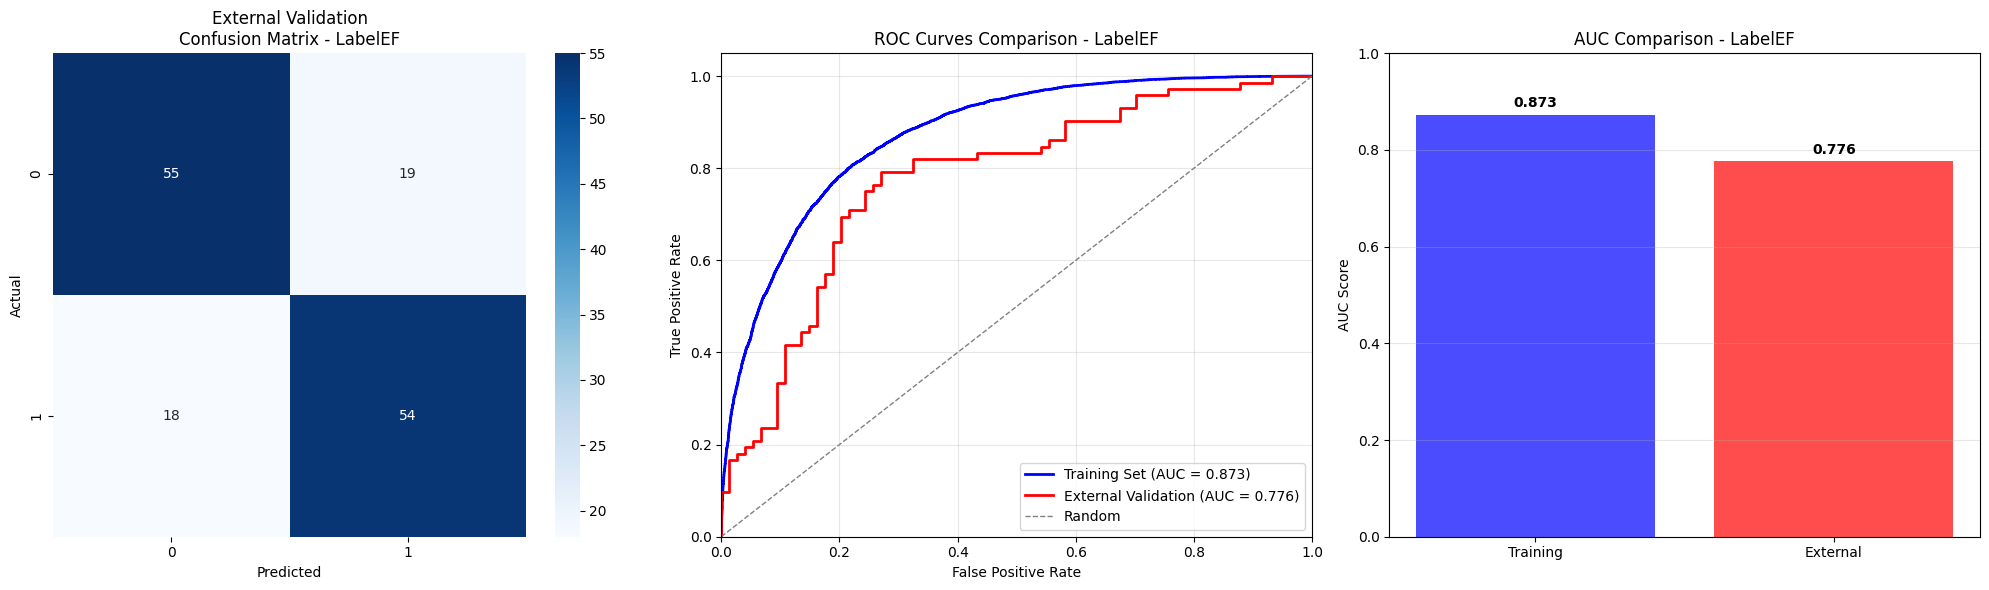

External Validation Results:
  AUC: 0.7761
  Accuracy: 0.7466
  Precision: 0.7397
  Recall: 0.7500
  F1-Score: 0.7448
Training vs External AUC Difference: 0.0969
✓ Acceptable performance on external validation

External Validation: LabelCO


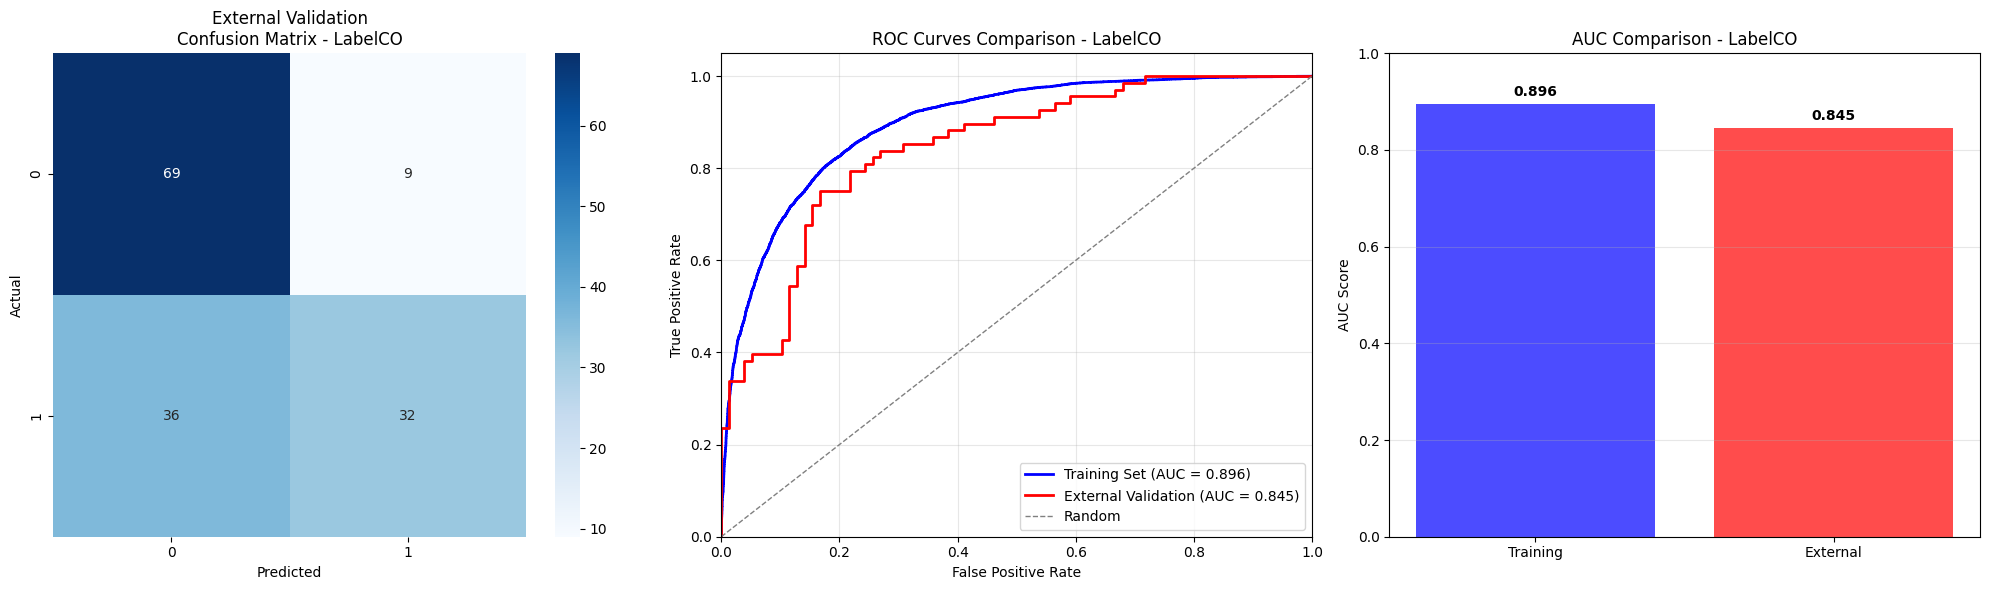

External Validation Results:
  AUC: 0.8454
  Accuracy: 0.6918
  Precision: 0.7805
  Recall: 0.4706
  F1-Score: 0.5872
Training vs External AUC Difference: 0.0504
✓ Acceptable performance on external validation

External Validation: LabelLAV


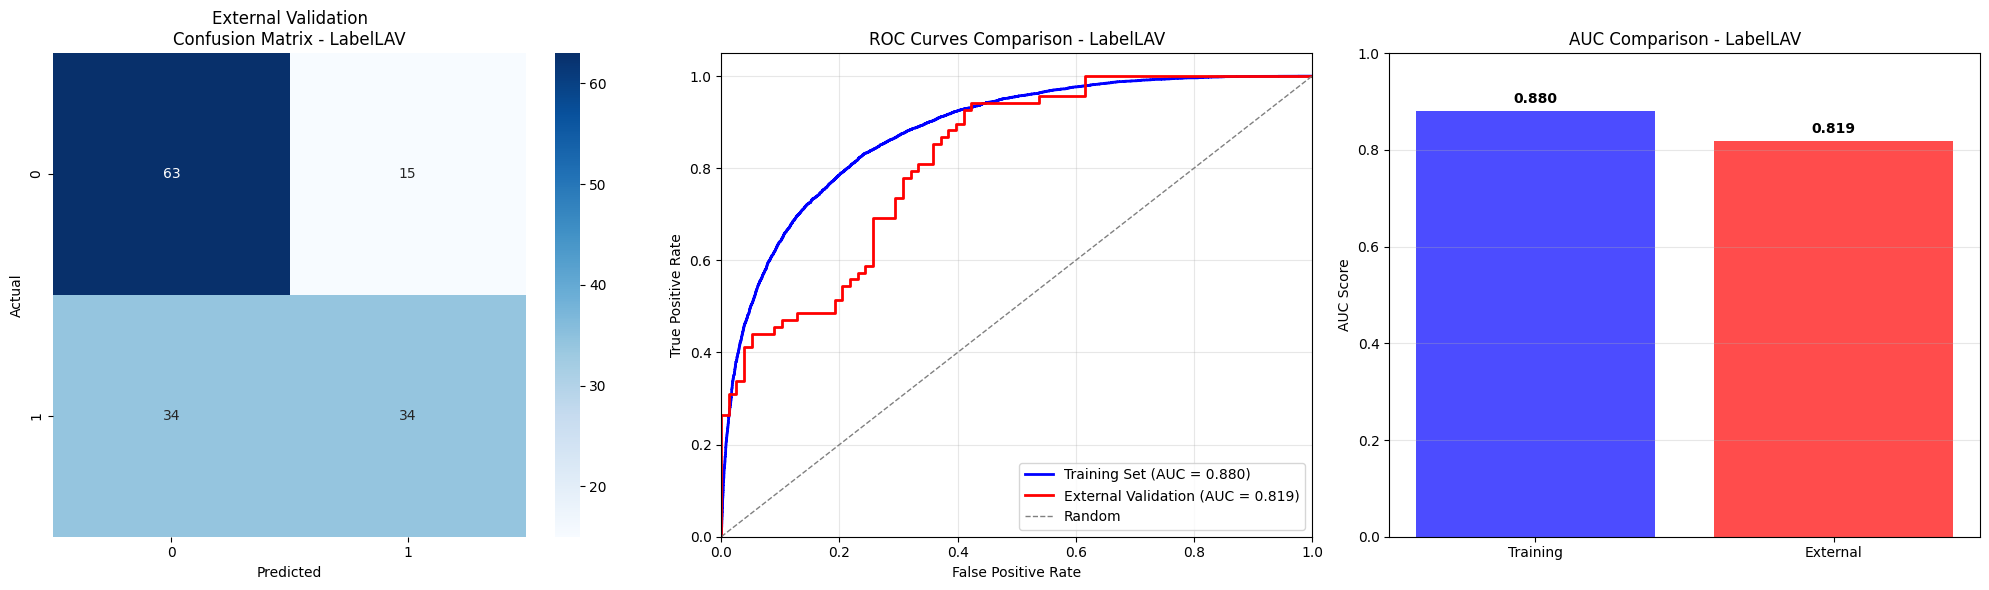

External Validation Results:
  AUC: 0.8190
  Accuracy: 0.6644
  Precision: 0.6939
  Recall: 0.5000
  F1-Score: 0.5812
Training vs External AUC Difference: 0.0608
✓ Acceptable performance on external validation

External Validation: LabelRVO2E


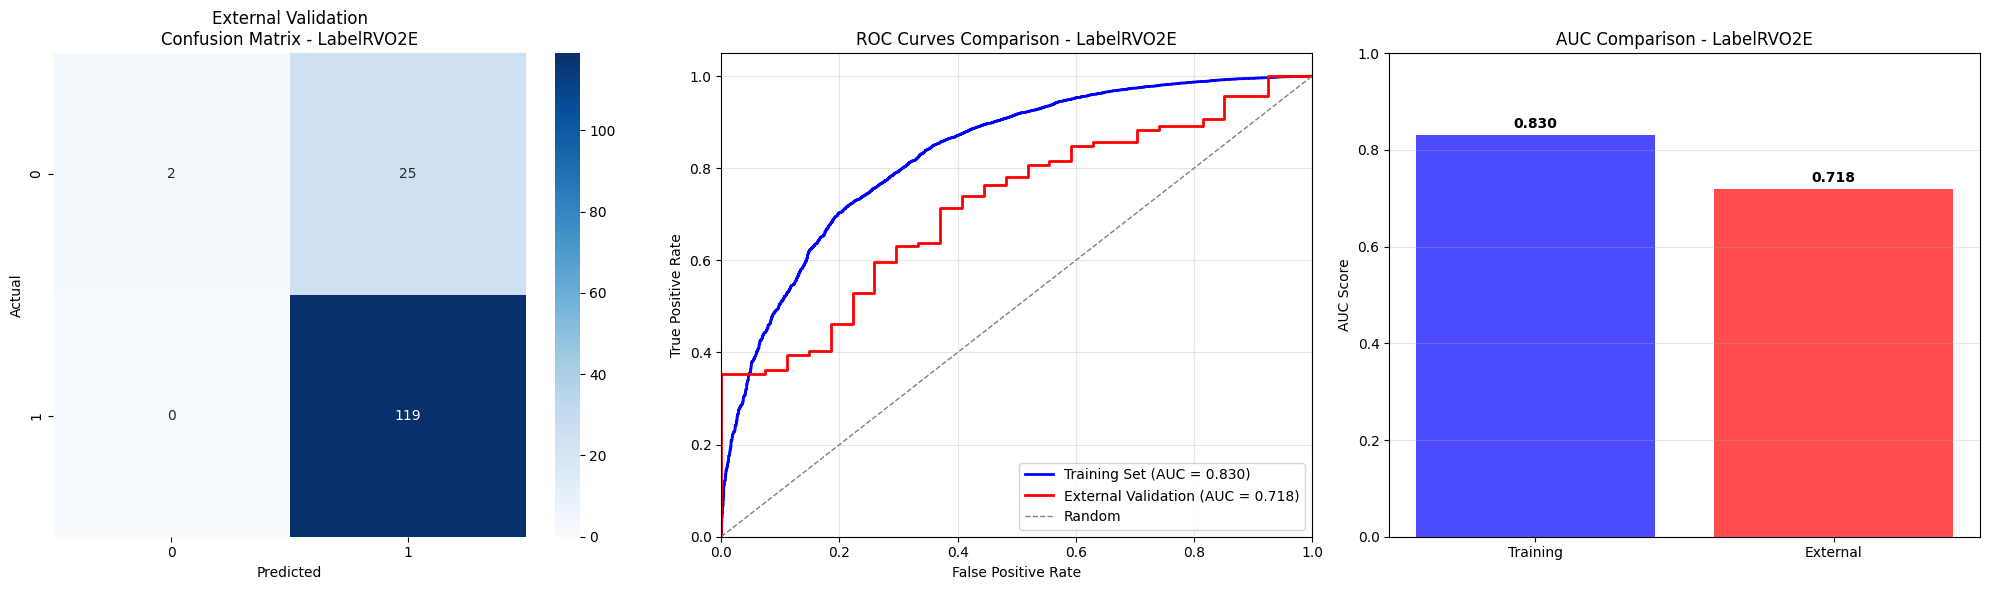

External Validation Results:
  AUC: 0.7183
  Accuracy: 0.8288
  Precision: 0.8264
  Recall: 1.0000
  F1-Score: 0.9049
Training vs External AUC Difference: 0.1116
⚠️  Large performance drop detected - possible overfitting

External Validation: LabelLVO2E


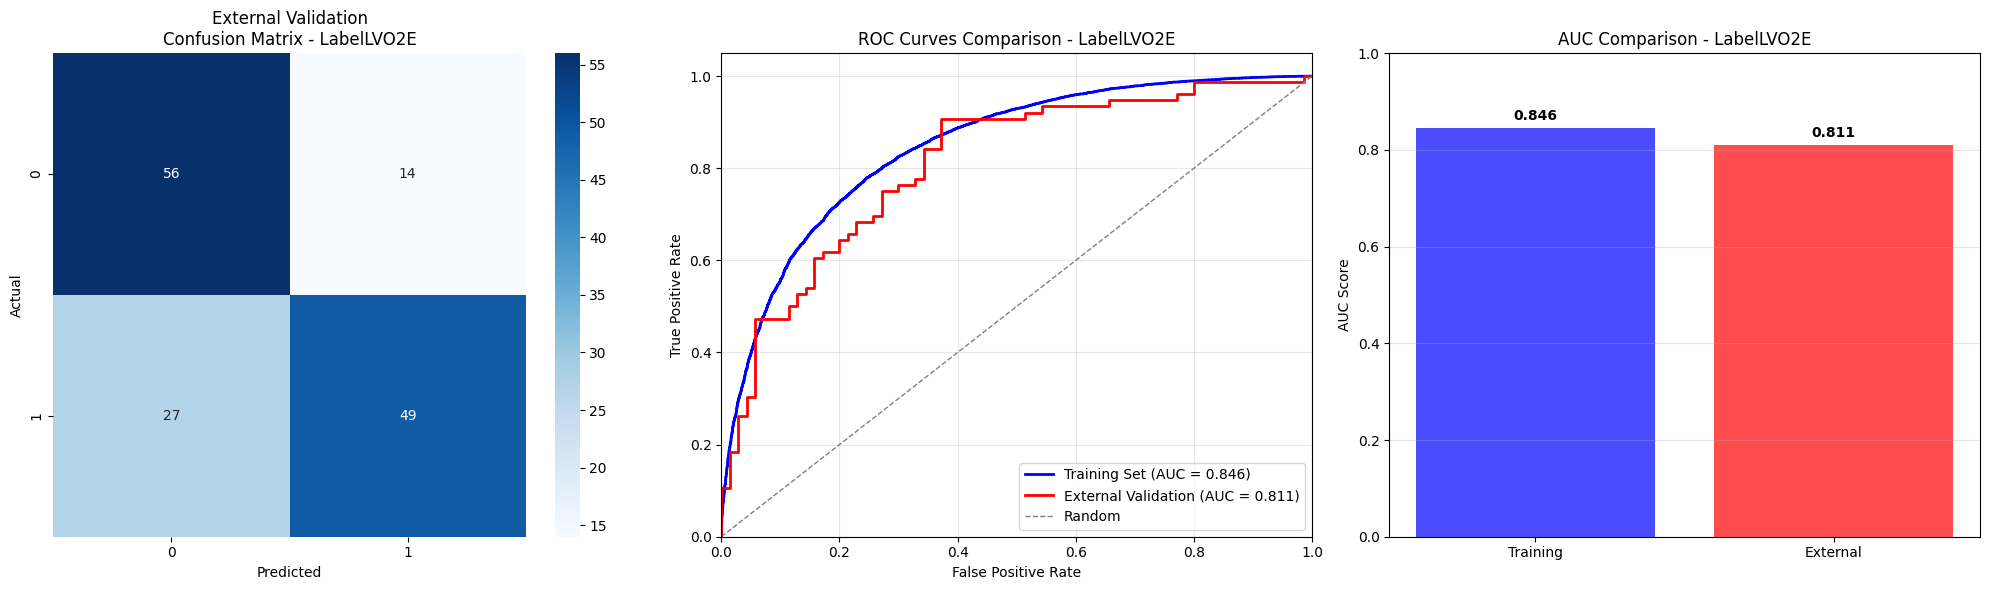

External Validation Results:
  AUC: 0.8105
  Accuracy: 0.7192
  Precision: 0.7778
  Recall: 0.6447
  F1-Score: 0.7050
Training vs External AUC Difference: 0.0355
✓ Acceptable performance on external validation

External Validation: LabelLVMVO2


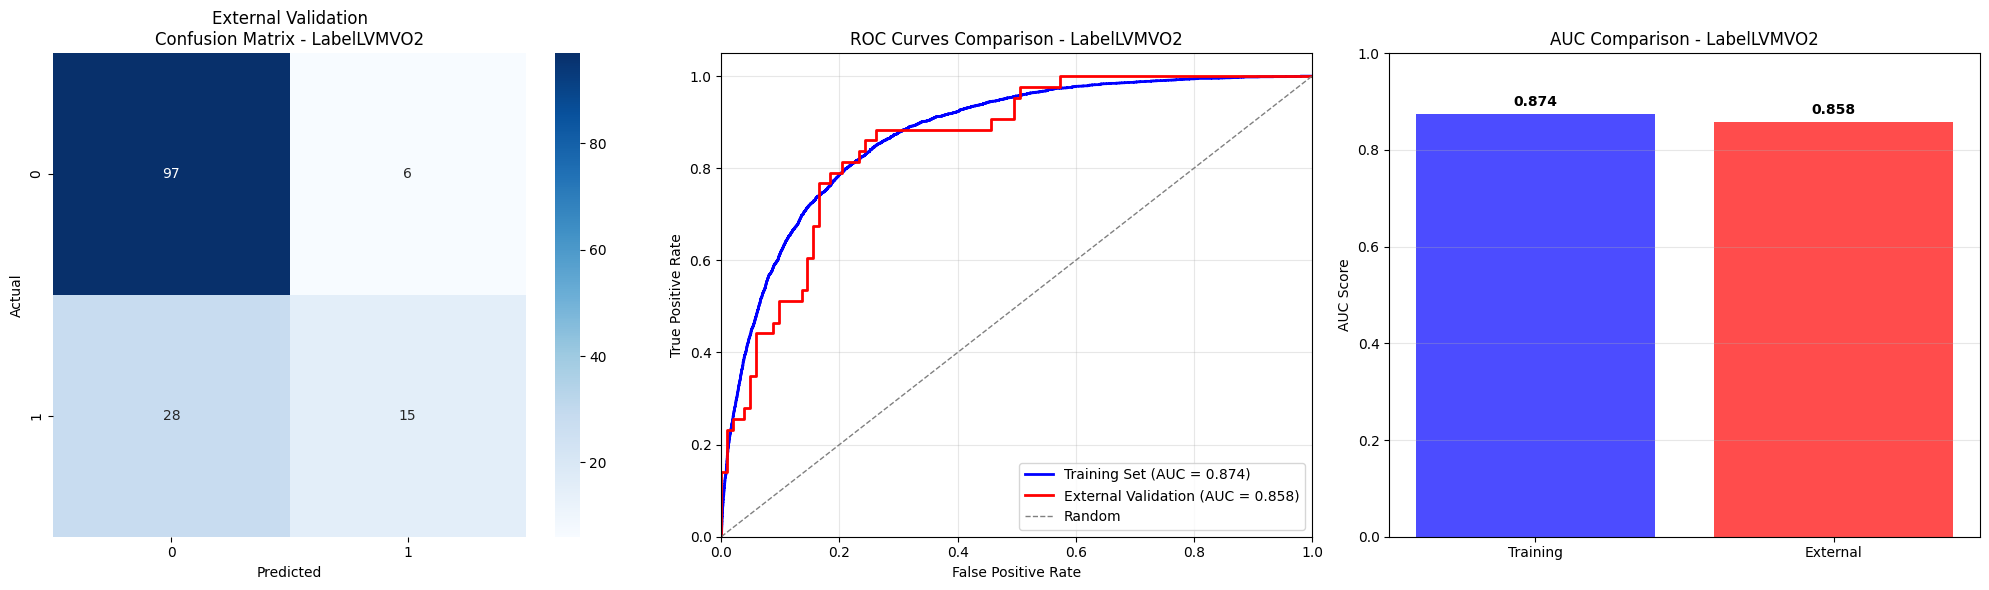

External Validation Results:
  AUC: 0.8580
  Accuracy: 0.7671
  Precision: 0.7143
  Recall: 0.3488
  F1-Score: 0.4688
Training vs External AUC Difference: 0.0158
✓ Acceptable performance on external validation

External Validation: LabelRVMVO2


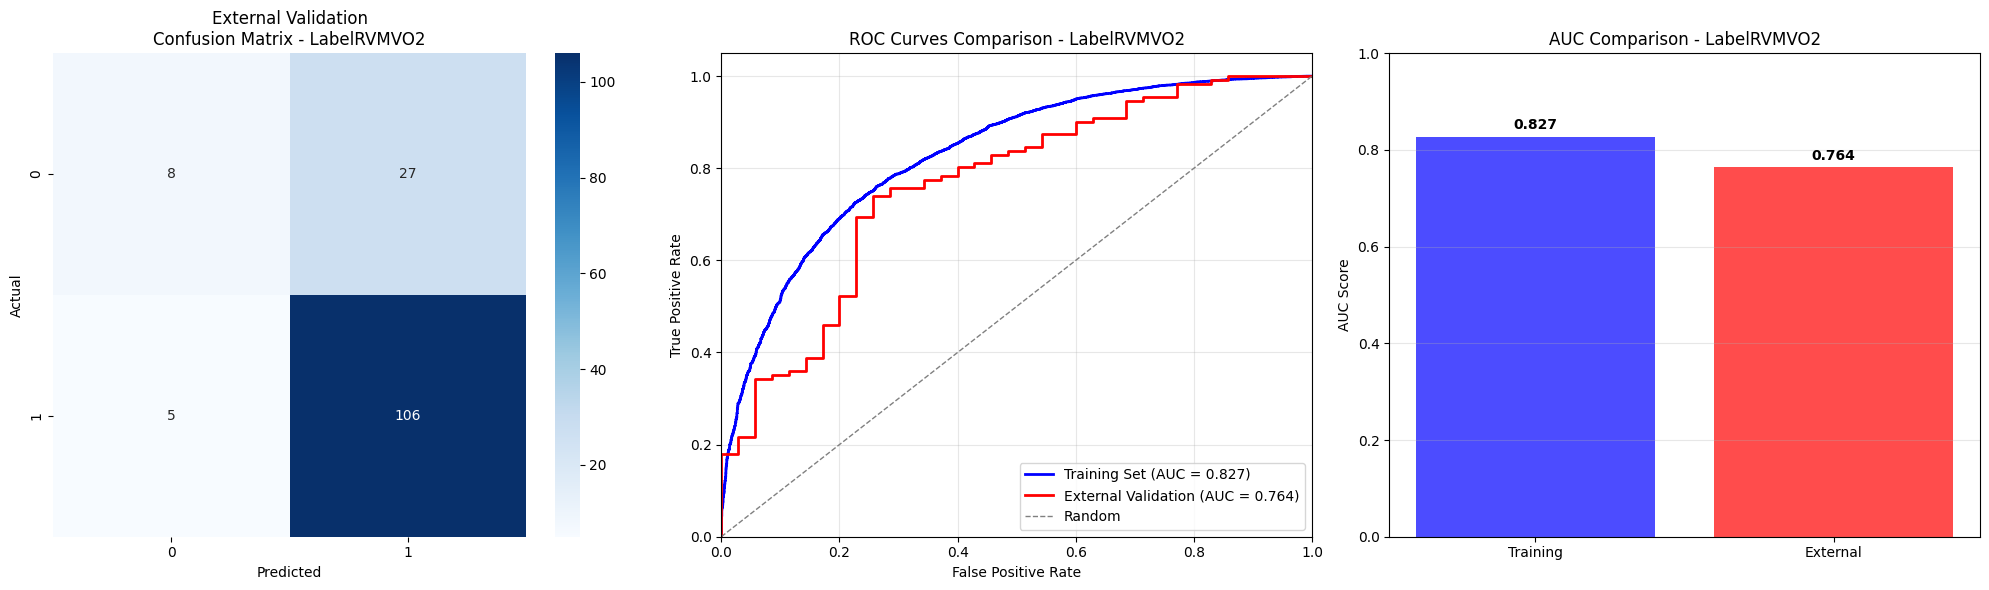

External Validation Results:
  AUC: 0.7637
  Accuracy: 0.7808
  Precision: 0.7970
  Recall: 0.9550
  F1-Score: 0.8689
Training vs External AUC Difference: 0.0638
✓ Acceptable performance on external validation

External Validation: LabelLVME


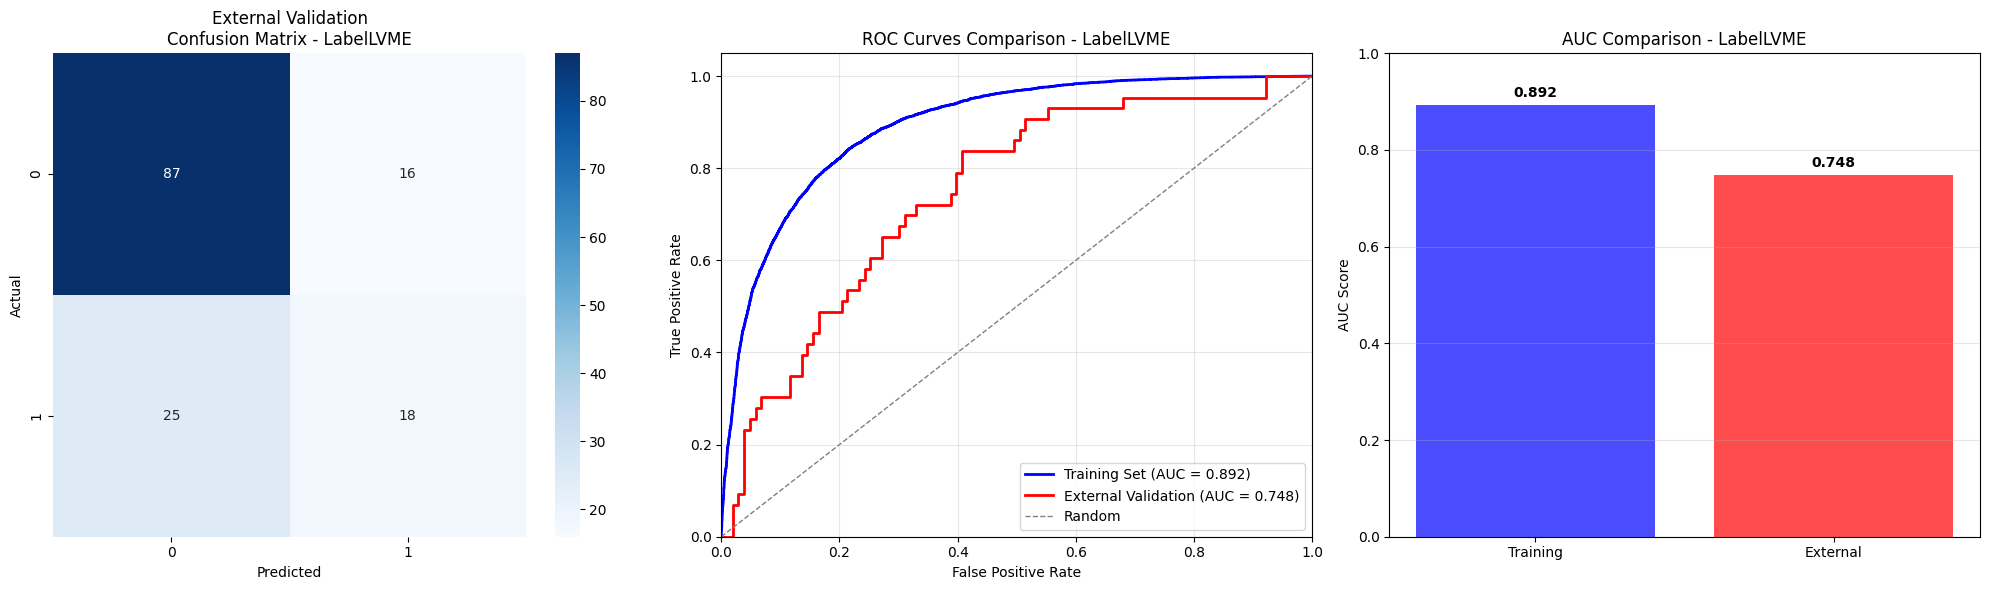

External Validation Results:
  AUC: 0.7476
  Accuracy: 0.7192
  Precision: 0.5294
  Recall: 0.4186
  F1-Score: 0.4675
Training vs External AUC Difference: 0.1446
⚠️  Large performance drop detected - possible overfitting

External Validation: LabelRVME


c:\github\Haolin_24Winter_Danlab\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\github\Haolin_24Winter_Danlab\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\github\Haolin_24Winter_Danlab\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

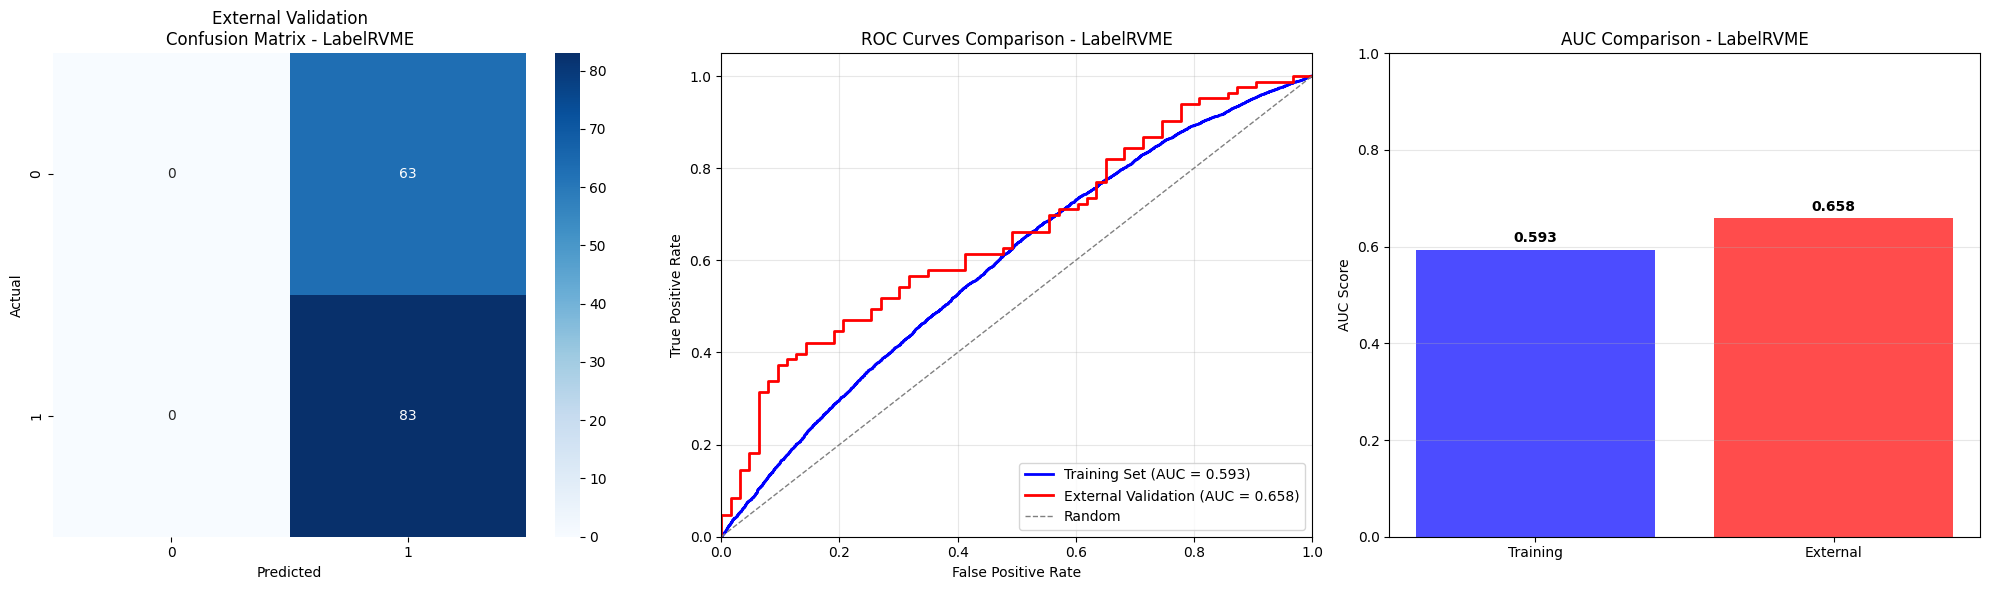

External Validation Results:
  AUC: 0.6581
  Accuracy: 0.5685
  Precision: 0.5685
  Recall: 1.0000
  F1-Score: 0.7249
Training vs External AUC Difference: -0.0653
✓ External validation performance better than training - good generalization

EXTERNAL VALIDATION COMPLETED!
All external validation plots saved in: external_validation_plots/

SUMMARY: Training vs External Validation Performance
Label           Train AUC  External AUC  Difference Status
-----------------------------------------------------------------
LabelFillingP   0.8937     0.7697        0.1240     ⚠️ Large Gap
LabelEF         0.8610     0.7761        0.0849     ✓ Good
LabelCO         0.8864     0.8454        0.0410     ✓ Good
LabelLAV        0.8669     0.8190        0.0479     ✓ Good
LabelRVO2E      0.8169     0.7183        0.0985     ✓ Good
LabelLVO2E      0.8258     0.8105        0.0153     ✓ Good
LabelLVMVO2     0.8498     0.8580        -0.0081    ✓ Better
LabelRVMVO2     0.8013     0.7637        0.0376     ✓ Good
La

In [38]:
# External Validation Set Evaluation
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load external validation dataset
print("="*80)
print("EXTERNAL VALIDATION SET EVALUATION")
print("="*80)

# Load the external validation data
df_external = pd.read_csv('inputFGclassifier146.CSV')
print(f"✓ Successfully loaded external validation data: inputFGclassifier146.CSV")

# Preprocess external validation data (same as training data preprocessing)
external_processed = df_external.drop(df_external.columns[[0, 12]], axis=1)
external_features = external_processed.iloc[:, 0:17]
external_labels = external_processed.iloc[:, -10:]

print(f"\nExternal validation data shape:")
print(f"Features shape: {external_features.shape}")
print(f"Labels shape: {external_labels.shape}")

# Normalize external features using the same preprocessing pipeline as training
external_continuous = external_features.iloc[:, 1:-1]
external_normalized = scaler.transform(external_continuous)  # Use existing scaler from training

# Combine binary and normalized continuous features (same as training)
external_normalized_df = pd.DataFrame(external_normalized, columns=external_continuous.columns)
external_normalized_df.insert(0, external_features.columns[0], external_features.iloc[:, 0])  # First binary column
external_normalized_df[external_features.columns[-1]] = external_features.iloc[:, -1]  # Last binary column

# Convert to PyTorch tensor
X_external_tensor = torch.tensor(external_normalized_df.values, dtype=torch.float32)

print(f"External validation tensor size: {X_external_tensor.size()}")
print(f"External validation labels columns: {external_labels.columns.tolist()}")

# Create directory for external validation plots
external_plot_dir = "external_validation_plots"
os.makedirs(external_plot_dir, exist_ok=True)

print("\n" + "="*80)
print("EVALUATING ALL CLASSIFIERS ON EXTERNAL VALIDATION SET")
print("="*80)

# Dictionary to store external validation results
external_results = {}

# Evaluate each trained model on external validation set
for i in range(labels.shape[1]):
    label_name = labels.columns[i]
    print(f"\n{'='*60}")
    print(f"External Validation: {label_name}")
    print(f"{'='*60}")
    
    # Load the best model
    model_path = os.path.join(save_dir, f"model_{label_name}_best.pth")
    if os.path.exists(model_path):
        # Initialize and load model
        eval_model = MLPClassifier(input_size=17).to(device)
        eval_model.load_state_dict(torch.load(model_path, map_location=device))
        eval_model.eval()
        
        # Get predictions on external validation set
        with torch.no_grad():
            X_external_device = X_external_tensor.to(device)
            external_outputs = eval_model(X_external_device)
            external_probs = external_outputs.cpu().numpy().flatten()
            external_preds = (external_probs > 0.5).astype(int)
            external_true = external_labels.iloc[:, i].values.astype(int)
        
        # Get training set predictions for comparison
        with torch.no_grad():
            X_train_device = X_train_tensor.to(device)
            train_outputs = eval_model(X_train_device)
            train_probs = train_outputs.cpu().numpy().flatten()
            train_true = y_train_tensor[:, i].numpy().astype(int)
        
        # Calculate metrics for external validation
        external_auc = roc_auc_score(external_true, external_probs)
        external_cm = confusion_matrix(external_true, external_preds)
        external_report = classification_report(external_true, external_preds, output_dict=True)
        
        # Calculate ROC curves
        external_fpr, external_tpr, _ = roc_curve(external_true, external_probs)
        train_fpr, train_tpr, _ = roc_curve(train_true, train_probs)
        
        # Store results
        external_results[label_name] = {
            'external_auc': external_auc,
            'external_cm': external_cm,
            'external_report': external_report,
            'external_fpr': external_fpr,
            'external_tpr': external_tpr
        }
        
        # Create comprehensive visualization
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        
        # 1. External Validation Confusion Matrix
        sns.heatmap(external_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
        axes[0].set_title(f'External Validation\nConfusion Matrix - {label_name}')
        axes[0].set_xlabel('Predicted')
        axes[0].set_ylabel('Actual')
        
        # 2. Training vs External ROC Comparison
        axes[1].plot(train_fpr, train_tpr, color='blue', lw=2, 
                    label=f'Training Set (AUC = {roc_auc_score(train_true, train_probs):.3f})')
        axes[1].plot(external_fpr, external_tpr, color='red', lw=2, 
                    label=f'External Validation (AUC = {external_auc:.3f})')
        axes[1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random')
        axes[1].set_xlim([0.0, 1.0])
        axes[1].set_ylim([0.0, 1.05])
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title(f'ROC Curves Comparison - {label_name}')
        axes[1].legend(loc="lower right")
        axes[1].grid(True, alpha=0.3)
        
        # 3. Performance Metrics Comparison
        train_auc = roc_auc_score(train_true, train_probs)
        metrics_comparison = {
            'AUC': [train_auc, external_auc],
            'Dataset': ['Training', 'External']
        }
        
        bars = axes[2].bar(['Training', 'External'], [train_auc, external_auc], 
                          color=['blue', 'red'], alpha=0.7)
        axes[2].set_ylim([0, 1])
        axes[2].set_ylabel('AUC Score')
        axes[2].set_title(f'AUC Comparison - {label_name}')
        axes[2].grid(True, alpha=0.3, axis='y')
        
        # Add value labels on bars
        for bar, value in zip(bars, [train_auc, external_auc]):
            height = bar.get_height()
            axes[2].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                        f'{value:.3f}', ha='center', va='bottom', fontweight='bold')
        
        plt.tight_layout()
        plt.savefig(os.path.join(external_plot_dir, f'{label_name}_external_validation.png'), 
                   dpi=300, bbox_inches='tight')
        plt.show()
        
        # Print detailed metrics
        print(f"External Validation Results:")
        print(f"  AUC: {external_auc:.4f}")
        print(f"  Accuracy: {external_report['accuracy']:.4f}")
        if '1' in external_report:
            print(f"  Precision: {external_report['1']['precision']:.4f}")
            print(f"  Recall: {external_report['1']['recall']:.4f}")
            print(f"  F1-Score: {external_report['1']['f1-score']:.4f}")
        
        print(f"Training vs External AUC Difference: {train_auc - external_auc:.4f}")
        
        if abs(train_auc - external_auc) > 0.1:
            print("⚠️  Large performance drop detected - possible overfitting")
        elif external_auc > train_auc:
            print("✓ External validation performance better than training - good generalization")
        else:
            print("✓ Acceptable performance on external validation")
            
    else:
        print(f"❌ Model file not found: {model_path}")

print("\n" + "="*80)
print("EXTERNAL VALIDATION COMPLETED!")
print(f"All external validation plots saved in: {external_plot_dir}/")
print("="*80)

# Summary table of all results
print(f"\n{'='*80}")
print("SUMMARY: Training vs External Validation Performance")
print(f"{'='*80}")
print(f"{'Label':<15} {'Train AUC':<10} {'External AUC':<13} {'Difference':<10} {'Status'}")
print("-" * 65)

for label_name in labels.columns:
    if label_name in external_results:
        # Get training AUC from evaluation_results if available
        if label_name in evaluation_results:
            train_auc = evaluation_results[label_name]['auc']
        else:
            # Fallback: load model and calculate
            model_path = os.path.join(save_dir, f"model_{label_name}_best.pth")
            if os.path.exists(model_path):
                eval_model = MLPClassifier(input_size=17).to(device)
                eval_model.load_state_dict(torch.load(model_path, map_location=device))
                eval_model.eval()
                with torch.no_grad():
                    X_train_device = X_train_tensor.to(device)
                    train_outputs = eval_model(X_train_device)
                    train_probs = train_outputs.cpu().numpy().flatten()
                    train_true = y_train_tensor[:, list(labels.columns).index(label_name)].numpy().astype(int)
                    train_auc = roc_auc_score(train_true, train_probs)
            else:
                train_auc = 0.0
                
        external_auc = external_results[label_name]['external_auc']
        diff = train_auc - external_auc
        
        if abs(diff) > 0.1:
            status = "⚠️ Large Gap"
        elif external_auc > train_auc:
            status = "✓ Better"
        else:
            status = "✓ Good"
            
        print(f"{label_name:<15} {train_auc:<10.4f} {external_auc:<13.4f} {diff:<10.4f} {status}")

print(f"\n✓ External validation complete! 146 patients evaluated across all 10 classifiers.")

In [41]:
# MYPACE Dataset Prediction with Missing Data Imputation
from sklearn.impute import KNNImputer
import pandas as pd
import numpy as np
import torch

print("="*80)
print("MYPACE DATASET PREDICTION")
print("="*80)

# Load MYPACE dataset
mypace_file_path = "inputFGclassifierMYPACE.CSV"
df_mypace = pd.read_csv(mypace_file_path)
print(f"✓ Successfully loaded MYPACE data from: {mypace_file_path}")
print(f"Original MYPACE data shape: {df_mypace.shape}")

# Display basic info about the dataset
print(f"\nMYPACE Dataset Info:")
print(f"Number of rows: {len(df_mypace)}")
print(f"Number of columns: {len(df_mypace.columns)}")
print(f"Column names: {df_mypace.columns.tolist()}")

# Clean and standardize missing values first
print(f"\n🔧 Cleaning missing values...")
# Replace various missing value representations with NaN
missing_values = ['N/a', 'n/a', 'N/A', 'NA', 'na', 'NaN', 'nan', '', ' ', 'null', 'NULL']
df_mypace = df_mypace.replace(missing_values, np.nan)

# Convert all columns to numeric where possible
for col in df_mypace.columns:
    try:
        df_mypace[col] = pd.to_numeric(df_mypace[col], errors='coerce')
    except:
        pass

print(f"✓ Missing value representations standardized to NaN")

# Check for missing values
missing_info = df_mypace.isnull().sum()
missing_percentage = (missing_info / len(df_mypace)) * 100
print(f"\nMissing Value Analysis:")
print("-" * 50)
for col, missing_count in missing_info.items():
    if missing_count > 0:
        print(f"{col:20s}: {missing_count:3d} missing ({missing_percentage[col]:.1f}%)")

total_missing = missing_info.sum()
if total_missing > 0:
    print(f"\nTotal missing values: {total_missing}")
else:
    print(f"\n✓ No missing values found in the dataset")

# Preprocess MYPACE data (same structure as training data)
# Remove the same columns as in training (column 0 and 12)
mypace_processed = df_mypace.drop(df_mypace.columns[[0, 12]], axis=1)

# Extract features (first 17 columns after preprocessing)
mypace_features = mypace_processed.iloc[:, 0:17]
print(f"\nMYPACE Features shape after preprocessing: {mypace_features.shape}")
print(f"Feature columns: {mypace_features.columns.tolist()}")

# Identify categorical columns (binary variables - first and last feature columns)
categorical_cols = [mypace_features.columns[0], mypace_features.columns[-1]]  # First and last columns
continuous_cols = mypace_features.columns[1:-1].tolist()  # Middle columns

print(f"\nCategorical columns (binary): {categorical_cols}")
print(f"Continuous columns: {continuous_cols}")

# Handle missing values using KNNImputer with K=5
if mypace_features.isnull().sum().sum() > 0:
    print(f"\n🔧 Applying KNN Imputation (K=5) for missing values...")
    
    # Separate categorical and continuous features for appropriate imputation
    mypace_categorical = mypace_features[categorical_cols].copy()
    mypace_continuous = mypace_features[continuous_cols].copy()
    
    # Check missing values in each type
    cat_missing = mypace_categorical.isnull().sum().sum()
    cont_missing = mypace_continuous.isnull().sum().sum()
    
    print(f"Missing in categorical features: {cat_missing}")
    print(f"Missing in continuous features: {cont_missing}")
    
    # Apply KNN imputation
    if cont_missing > 0:
        # For continuous features, use KNN imputation
        knn_imputer = KNNImputer(n_neighbors=5)
        mypace_continuous_imputed = knn_imputer.fit_transform(mypace_continuous)
        mypace_continuous_imputed = pd.DataFrame(mypace_continuous_imputed, 
                                                columns=mypace_continuous.columns,
                                                index=mypace_continuous.index)
        print(f"✓ KNN imputation applied to continuous features")
    else:
        mypace_continuous_imputed = mypace_continuous.copy()
    
    if cat_missing > 0:
        # For categorical features, use mode imputation or KNN with rounding
        knn_cat_imputer = KNNImputer(n_neighbors=5)
        mypace_categorical_imputed = knn_cat_imputer.fit_transform(mypace_categorical)
        # Round to nearest integer for binary variables
        mypace_categorical_imputed = np.round(mypace_categorical_imputed).astype(int)
        mypace_categorical_imputed = pd.DataFrame(mypace_categorical_imputed,
                                                 columns=mypace_categorical.columns,
                                                 index=mypace_categorical.index)
        print(f"✓ KNN imputation with rounding applied to categorical features")
    else:
        mypace_categorical_imputed = mypace_categorical.copy()
    
    # Combine imputed features
    mypace_features_imputed = pd.concat([
        mypace_categorical_imputed.iloc[:, [0]],  # First categorical column
        mypace_continuous_imputed,                 # All continuous columns
        mypace_categorical_imputed.iloc[:, [1]]   # Last categorical column
    ], axis=1)
    
    print(f"✓ Imputation completed. No missing values remaining: {mypace_features_imputed.isnull().sum().sum() == 0}")
    
else:
    mypace_features_imputed = mypace_features.copy()
    print(f"✓ No missing values to impute")

# Normalize MYPACE features using the same preprocessing pipeline as training
print(f"\n🔧 Normalizing MYPACE features using training scaler...")
mypace_continuous_imputed = mypace_features_imputed.iloc[:, 1:-1]
mypace_normalized = scaler.transform(mypace_continuous_imputed)  # Use existing scaler from training

# Combine binary and normalized continuous features (same as training)
mypace_normalized_df = pd.DataFrame(mypace_normalized, columns=mypace_continuous_imputed.columns)
mypace_normalized_df.insert(0, mypace_features_imputed.columns[0], mypace_features_imputed.iloc[:, 0])  # First binary column
mypace_normalized_df[mypace_features_imputed.columns[-1]] = mypace_features_imputed.iloc[:, -1]  # Last binary column

# Convert to PyTorch tensor
X_mypace_tensor = torch.tensor(mypace_normalized_df.values, dtype=torch.float32)

print(f"✓ MYPACE tensor ready for prediction: {X_mypace_tensor.size()}")

# Predict labels using all trained classifiers
print(f"\n{'='*80}")
print("PREDICTING LABELS FOR MYPACE DATASET")
print(f"{'='*80}")

# Dictionary to store predictions
mypace_predictions = {}
mypace_probabilities = {}

# Predict using each trained model
for i, label_name in enumerate(labels.columns):
    print(f"\nPredicting {label_name}...")
    
    # Load the best model
    model_path = os.path.join(save_dir, f"model_{label_name}_best.pth")
    if os.path.exists(model_path):
        # Initialize and load model
        eval_model = MLPClassifier(input_size=17).to(device)
        eval_model.load_state_dict(torch.load(model_path, map_location=device))
        eval_model.eval()
        
        # Get predictions
        with torch.no_grad():
            X_mypace_device = X_mypace_tensor.to(device)
            mypace_outputs = eval_model(X_mypace_device)
            mypace_probs = mypace_outputs.cpu().numpy().flatten()
            mypace_preds = (mypace_probs > 0.5).astype(int)
        
        # Store predictions
        mypace_predictions[label_name] = mypace_preds
        mypace_probabilities[label_name] = mypace_probs
        
        # Print prediction statistics
        positive_count = np.sum(mypace_preds)
        positive_rate = positive_count / len(mypace_preds)
        mean_prob = np.mean(mypace_probs)
        
        print(f"  Positive predictions: {positive_count}/{len(mypace_preds)} ({positive_rate:.3f})")
        print(f"  Mean probability: {mean_prob:.4f}")
        print(f"  Probability range: [{np.min(mypace_probs):.4f}, {np.max(mypace_probs):.4f}]")
        
    else:
        print(f"❌ Model file not found: {model_path}")
        mypace_predictions[label_name] = np.zeros(len(df_mypace), dtype=int)
        mypace_probabilities[label_name] = np.zeros(len(df_mypace))

# Create results DataFrame
print(f"\n{'='*80}")
print("CREATING RESULTS TABLE")
print(f"{'='*80}")

# Start with original MYPACE data
df_mypace_with_predictions = df_mypace.copy()

# Add predicted labels and probabilities
for label_name in labels.columns:
    # Add binary predictions
    df_mypace_with_predictions[f'{label_name}'] = mypace_predictions[label_name]
    # Add probability scores (rounded to 4 decimal places for consistency)
    df_mypace_with_predictions[f'{label_name}_prob'] = np.round(mypace_probabilities[label_name], 4)

print(f"✓ Added predictions for all {len(labels.columns)} labels")
print(f"Final dataset shape: {df_mypace_with_predictions.shape}")

# Display prediction summary
print(f"\n📊 PREDICTION SUMMARY:")
print("-" * 80)
print(f"{'Label':<15} {'Negative (0)':<12} {'Positive (1)':<12} {'Pos Rate':<10} {'Mean Prob':<10}")
print("-" * 80)
for label_name in labels.columns:
    preds = mypace_predictions[label_name]
    probs = mypace_probabilities[label_name]
    
    # Count 0s and 1s
    neg_count = np.sum(preds == 0)  # Count of 0s (negative predictions)
    pos_count = np.sum(preds == 1)  # Count of 1s (positive predictions)
    pos_rate = pos_count / len(preds)
    mean_prob = np.mean(probs)
    
    print(f"{label_name:<15} {neg_count:<12} {pos_count:<12} {pos_rate:<10.3f} {mean_prob:<10.4f}")

# Additional detailed breakdown
print(f"\n📈 DETAILED PREDICTION BREAKDOWN:")
print("-" * 80)
total_patients = len(df_mypace)
print(f"Total patients processed: {total_patients}")
print(f"Labels analyzed: {len(labels.columns)}")

for label_name in labels.columns:
    preds = mypace_predictions[label_name]
    probs = mypace_probabilities[label_name]
    
    neg_count = np.sum(preds == 0)
    pos_count = np.sum(preds == 1)
    
    print(f"\n{label_name}:")
    print(f"  Negative (0): {neg_count:3d} patients ({neg_count/total_patients*100:5.1f}%)")
    print(f"  Positive (1): {pos_count:3d} patients ({pos_count/total_patients*100:5.1f}%)")
    print(f"  Mean probability: {np.mean(probs):.4f}")
    print(f"  Prob range: [{np.min(probs):.4f}, {np.max(probs):.4f}]")

# Save results back to file
output_path = mypace_file_path.replace('.CSV', '_with_predictions.CSV')
df_mypace_with_predictions.to_csv(output_path, index=False)

print(f"\n✅ COMPLETED!")
print(f"Results saved to: {output_path}")
print(f"Total patients processed: {len(df_mypace)}")
print(f"Added {len(labels.columns)} label predictions and {len(labels.columns)} probability scores")
print(f"Output columns: {len(df_mypace_with_predictions.columns)} (original: {len(df_mypace.columns)})")

# Display first few rows of results
print(f"\n📋 Sample Results (first 5 rows, prediction columns only):")
prediction_columns = [col for col in df_mypace_with_predictions.columns if col in labels.columns or col.endswith('_prob')]
print(df_mypace_with_predictions[prediction_columns].head())

MYPACE DATASET PREDICTION
✓ Successfully loaded MYPACE data from: inputFGclassifierMYPACE.CSV
Original MYPACE data shape: (107, 29)

MYPACE Dataset Info:
Number of rows: 107
Number of columns: 29
Column names: ['Patient_No', 'Sex', 'Height', 'Weight', 'SBP', 'DBP', 'EF', 'Hed_SW', 'Hed_LW', 'HR', 'LAVmax', 'EAr', 'IVRT', 'LVIDd', 'LVIDs', 'LVEDV', 'LVESV', 'PASP', 'TVr', 'LabelFillingP', 'LabelEF', 'LabelCO', 'LabelLAV', 'LabelRVO2E', 'LabelLVO2E', 'LabelLVMVO2', 'LabelRVMVO2', 'LabelLVME', 'LabelRVME']

🔧 Cleaning missing values...
✓ Missing value representations standardized to NaN

Missing Value Analysis:
--------------------------------------------------
SBP                 :   2 missing (1.9%)
DBP                 :   2 missing (1.9%)
EF                  :   2 missing (1.9%)
Hed_SW              :  18 missing (16.8%)
Hed_LW              :  19 missing (17.8%)
HR                  :   4 missing (3.7%)
LAVmax              :   8 missing (7.5%)
EAr                 :  30 missing (28.0%)
IV